## Problem Overview and Cost Framework

This is a cost-sensitive classification problem with a goal of minimizing total monetary loss.

> “Lose the least amount possible on ALL unbiased predictions.”

| Prediction | Actual | Outcome | Cost |
| ---------- | ------ | ------- | ---- |
| 1          | 1      | TP      | \$0  |
| 0          | 0      | TN      | \$0  |
| 1          | 0      | **FP**  | \$27 |
| 0          | 1      | **FN**  | \$13 |


### Cost Prioritization

A false positive (predicting 1 incorrectly) is more costly than a false negative:
- Avoid false positives more than false negatives by being more conservative about predicting 1.

Recall (Sensitivity) = TP / (TP + FN) → Measures how well you find actual positives
Precision = TP / (TP + FP) → Measures how many of your positive predictions are correct

FPs cost more, therefore the precision of the positive class is more important than recall to minimize expensive false alarms.

In [1]:
# Define cost function (to use after predictions)
# FP → predict 1 but true = 0 → Cost: 27
# FN → predict 0 but true = 1 → Cost: 13

# total_cost = 27 * FP + 13 * FN
# cost = ((y_pred == 1) & (y_true == 0)) * 27 + ((y_pred == 0) & (y_true == 1)) * 13
# total_cost = cost.sum()

## Imports and Setup

In [2]:
# Core Python Libraries
import os
import glob
import shutil
import json
import time
import datetime
from itertools import product
import copy

# Data Manipulation and Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

%matplotlib inline

# Scikit-Learn: Preprocessing and Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.impute import SimpleImputer  # Uncomment if needed

# Scikit-Learn: Modeling and Evaluation
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, fbeta_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

# from sklearn.base import clone
# from sklearn.preprocessing import FunctionTransformer
# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.linear_model import SGDClassifier
# from sklearn.svm import SVC, LinearSVC
# from sklearn.metrics import log_loss
# from sklearn.metrics import RocCurveDisplay

# XGBoost
import xgboost as xgb

# PyTorch and Lightning
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

import lightning as pl
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from torchmetrics.classification import BinaryAUROC, BinaryPrecision

# Set Global Seed
SEED = 13

## Load and Inspect Data

In [3]:
raw_data = pd.read_csv('data/final_project(5).csv')
raw_data

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x41,x42,x43,x44,x45,x46,x47,x48,x49,y
0,-0.166563,-3.961588,4.621113,2.481908,-1.800135,0.804684,6.718751,-14.789997,-1.040673,-4.204950,...,-1.497117,5.414063,-2.325655,1.674827,-0.264332,60.781427,-7.689696,0.151589,-8.040166,0
1,-0.149894,-0.585676,27.839856,4.152333,6.426802,-2.426943,40.477058,-6.725709,0.896421,0.330165,...,36.292790,4.490915,0.762561,6.526662,1.007927,15.805696,-4.896678,-0.320283,16.719974,0
2,-0.321707,-1.429819,12.251561,6.586874,-5.304647,-11.311090,17.812850,11.060572,5.325880,-2.632984,...,-0.368491,9.088864,-0.689886,-2.731118,0.754200,30.856417,-7.428573,-2.090804,-7.869421,0
3,-0.245594,5.076677,-24.149632,3.637307,6.505811,2.290224,-35.111751,-18.913592,-0.337041,-5.568076,...,15.691546,-7.467775,2.940789,-6.424112,0.419776,-72.424569,5.361375,1.806070,-7.670847,0
4,-0.273366,0.306326,-11.352593,1.676758,2.928441,-0.616824,-16.505817,27.532281,1.199715,-4.309105,...,-13.911297,-5.229937,1.783928,3.957801,-0.096988,-14.085435,-0.208351,-0.894942,15.724742,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,-0.487024,-4.270269,0.417395,-1.992423,1.757552,-1.167819,0.606860,41.084463,-1.923188,-2.374213,...,-9.390451,8.096802,-0.875131,-1.413787,-0.363968,15.339392,4.364205,-3.831489,28.389858,1
159996,0.825477,4.804368,22.161535,11.371303,1.715901,6.990759,32.221207,-12.278038,-3.861086,6.715126,...,12.803189,0.841446,-0.682177,-5.047677,-0.017898,0.780130,6.387266,-1.374742,-1.623952,0
159997,-0.802489,5.362696,7.243419,-7.496074,2.295250,-2.756067,10.531388,42.515821,1.420984,6.788916,...,-0.346570,-0.144098,0.738298,7.241041,0.215347,-12.155249,3.265263,1.230963,3.335471,1
159998,0.339237,7.609895,5.368414,-2.825481,4.046102,15.322603,7.805271,-10.233054,2.609986,4.251127,...,-0.307656,-0.601145,-3.443112,0.549931,0.206728,5.081980,1.701462,-0.279619,-1.986424,0


In [4]:
raw_data.shape

(160000, 51)

In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 51 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   x0      159974 non-null  float64
 1   x1      159975 non-null  float64
 2   x2      159962 non-null  float64
 3   x3      159963 non-null  float64
 4   x4      159974 non-null  float64
 5   x5      159963 non-null  float64
 6   x6      159974 non-null  float64
 7   x7      159973 non-null  float64
 8   x8      159979 non-null  float64
 9   x9      159970 non-null  float64
 10  x10     159957 non-null  float64
 11  x11     159970 non-null  float64
 12  x12     159964 non-null  float64
 13  x13     159969 non-null  float64
 14  x14     159966 non-null  float64
 15  x15     159965 non-null  float64
 16  x16     159974 non-null  float64
 17  x17     159973 non-null  float64
 18  x18     159960 non-null  float64
 19  x19     159965 non-null  float64
 20  x20     159962 non-null  float64
 21  x21     15

In [6]:
# Are there an duplicated rows?
raw_data.duplicated().sum()

0

In [7]:
# How many missing values are there per column?
raw_data.isna().sum()

x0     26
x1     25
x2     38
x3     37
x4     26
x5     37
x6     26
x7     27
x8     21
x9     30
x10    43
x11    30
x12    36
x13    31
x14    34
x15    35
x16    26
x17    27
x18    40
x19    35
x20    38
x21    29
x22    27
x23    47
x24    28
x25    22
x26    36
x27    30
x28    35
x29    30
x30    30
x31    39
x32    31
x33    41
x34    41
x35    30
x36    27
x37    23
x38    31
x39    23
x40    36
x41    40
x42    26
x43    37
x44    40
x45    29
x46    31
x47    37
x48    32
x49    32
y       0
dtype: int64

In [8]:
min(raw_data.iloc[:,:-1].isna().sum())

21

In [9]:
print(max(raw_data.isna().sum()))
print(max(raw_data.isna().sum())/raw_data.shape[0] * 100)

47
0.029375000000000002


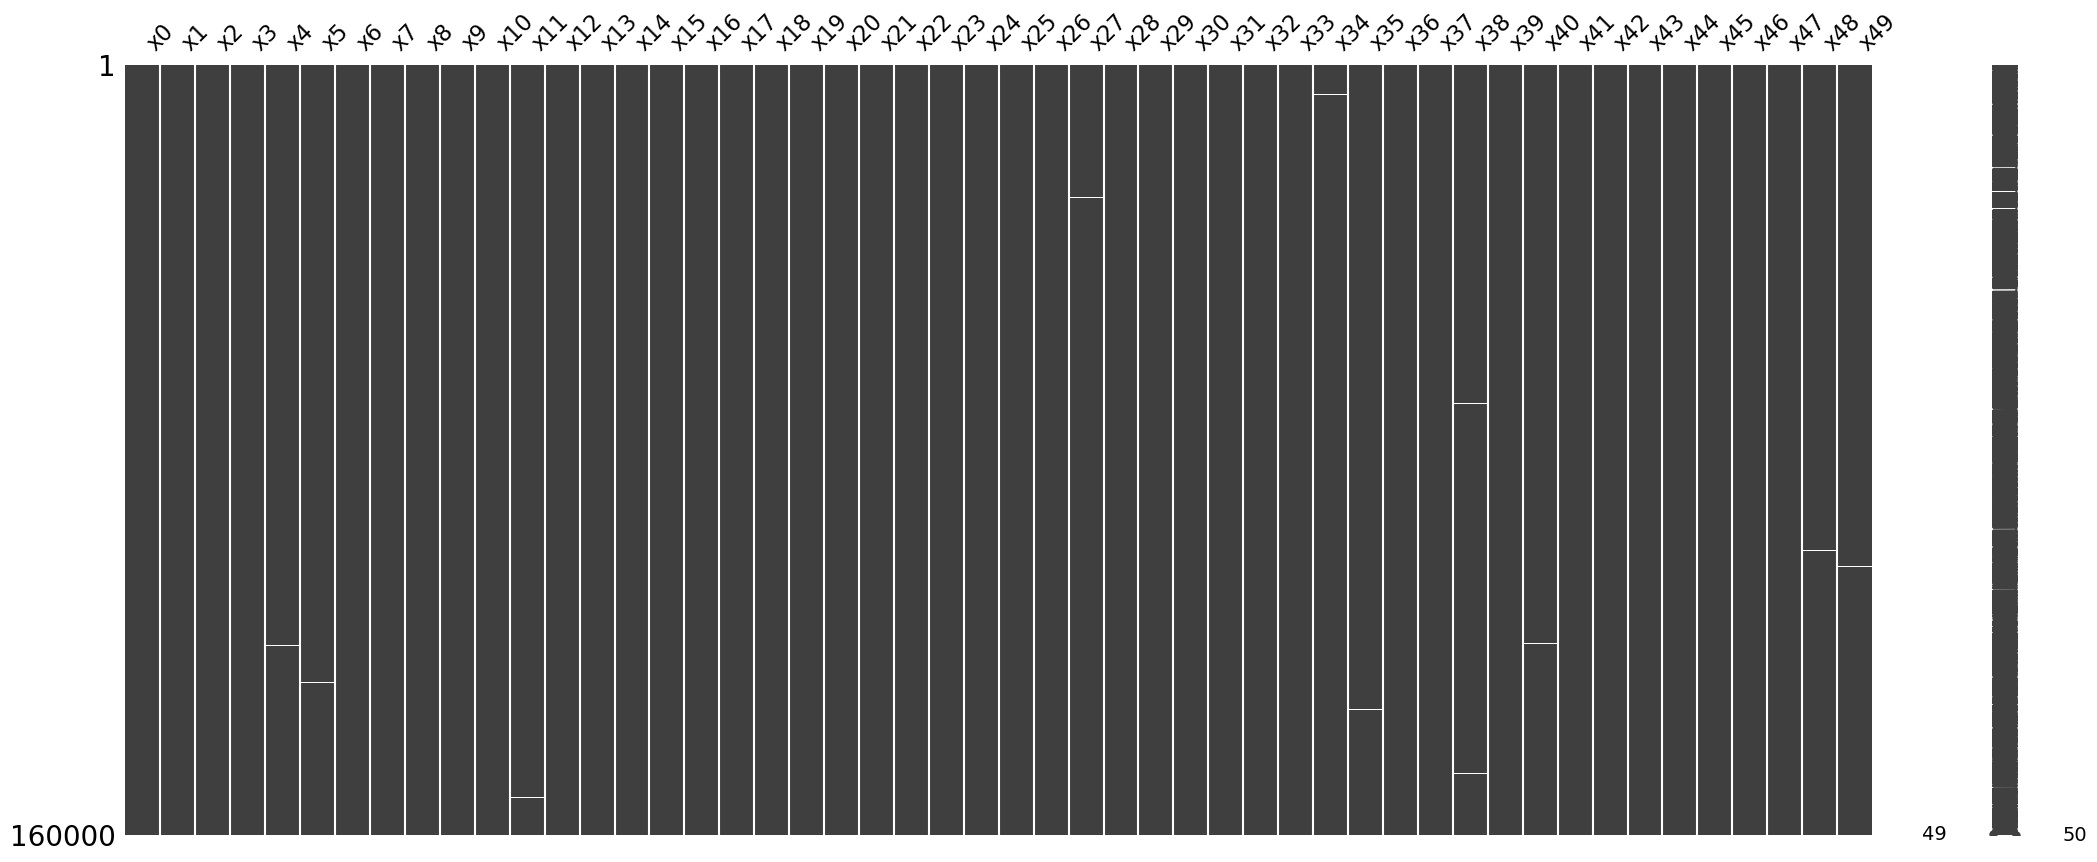

In [10]:
# Visualize missing data as a matrix
msno.matrix(raw_data.loc[:, raw_data.isnull().any()])
plt.show()

In [11]:
raw_data.dtypes.value_counts()

float64    45
object      5
int64       1
Name: count, dtype: int64

In [12]:
num_cols = raw_data.select_dtypes(include="number").columns
cat_cols = raw_data.select_dtypes(include=["object", "category"]).columns
print(cat_cols)

Index(['x24', 'x29', 'x30', 'x32', 'x37'], dtype='object')


In [13]:
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
x0,159974.0,-0.001028,0.371137,-1.592635,-0.251641,-0.002047,0.248532,1.600849
x1,159975.0,0.001358,6.340632,-26.278302,-4.260973,0.004813,4.284220,27.988178
x2,159962.0,-1.150145,13.273480,-59.394048,-10.166536,-1.340932,7.871676,63.545653
x3,159963.0,-0.024637,8.065032,-35.476594,-5.454438,-0.031408,5.445179,38.906025
x4,159974.0,-0.000549,6.382293,-28.467536,-4.313118,0.000857,4.306660,26.247812
x5,159963.0,0.013582,7.670076,-33.822988,-5.148130,0.014118,5.190749,35.550110
x6,159974.0,-1.670670,19.298665,-86.354483,-14.780146,-1.948594,11.446931,92.390605
x7,159973.0,-7.692795,30.542264,-181.506976,-27.324771,-6.956789,12.217071,149.150634
x8,159979.0,-0.030540,8.901185,-37.691045,-6.031058,-0.016840,5.972349,39.049831
x9,159970.0,0.005462,6.355040,-27.980659,-4.260619,0.006045,4.305734,27.377842


In [14]:
raw_data.describe(include=["object"])

,x24,x29,x30,x32,x37
count,159972,159970,159970,159969,159977
unique,3,12,5,12,129198
top,asia,July,wednesday,0.01%,$-311.26
freq,138965,45569,101535,40767,6


In [15]:
for col in cat_cols:
    print(raw_data[col].value_counts())
    print(raw_data[col].nunique())

x24
asia       138965
euorpe      16538
america      4469
Name: count, dtype: int64
3
x29
July       45569
Jun        41329
Aug        29406
May        21939
sept.      10819
Apr         6761
Oct         2407
Mar         1231
Nov          337
Feb          140
Dev           23
January        9
Name: count, dtype: int64
12
x30
wednesday    101535
thurday       29429
tuesday       27954
friday          564
monday          488
Name: count, dtype: int64
5
x32
0.01%     40767
-0.01%    34094
0.0%      33923
-0.0%     30492
-0.02%     9924
0.02%      7987
-0.03%     1727
0.03%       855
-0.04%      138
0.04%        55
-0.05%        6
0.05%         1
Name: count, dtype: int64
12
x37
$-311.26     6
$-336.77     6
$237.4       6
$72.42       6
$341.26      6
            ..
$-505.21     1
$770.07      1
$74.62       1
$-1082.96    1
$-1229.34    1
Name: count, Length: 129198, dtype: int64
129198


## Dataset Summary

Dataset:

- There are 50 features, 45 float64 and 5 object.
  - The 5 categorical features are:
    - continent or region
    - month
    - weekday (M-F)
    - percent (neg and pos)
    - dollar amount (neg and pos)
- The last column is the target variable (coded as int64).
- There are 160,000 observations.
- Every feature has between 21 and 47 missing values, fewer than 0.03% of data.
- There are no duplicate rows.
- There are two pairs of variables that are perfectly correlated (X38 & X41, X2 & X6).

Cleaning:

- The dollar amount and percent columns were converted to numeric after striping the dollar and percent signs.
- The month and weekday names were standardized. A separate month_num column was created by converting the month names to integers 1-12. The process was repeated for weekdays, creating a weekday_num column and converting them to 1-5.
- The region names were also standardized, but they were retained as categorical.

Imputation:

- x41 and X2 were imputed by modeling their linear relationship with their perfect correlated pair.
  - There was no overlap in missing rows between the correlated pairs.
  - X41 was calulated with 1.1059 * x38.
  - X2 was calculated with 0.6878 * x6.
- The month and weekday categorical columns were imputed with the mode and the corresponding integer values were used to impute the numerical columns.
- The region was imputed with the mode.
- The rest of the numeric variables were imputed with the median from the full column.

## Data Cleaning

It makes sense to convert dollar amounts to floats after removing the $. Also, renaming the column would help.

In [16]:
# Make a copy of the dataset
clean_data = raw_data.copy()

print(clean_data['x37'])

# Rename the x37 column x37_dollar_amt
clean_data.rename(columns={'x37': 'x37_dollar_amt'}, inplace=True)

# Remove $ and convert to float
clean_data['x37_dollar_amt'] = (
    clean_data['x37_dollar_amt']
        .astype(str)
        .str.strip()
        .str.replace('$', '', regex=False)
        .astype(float)
)

print(clean_data['x37_dollar_amt'])
print(clean_data.columns)
print(clean_data['x37_dollar_amt'].isna().sum())

0          $1313.96
1          $1962.78
2           $430.47
3         $-2366.29
4          $-620.66
            ...    
159995     $-891.96
159996     $1588.65
159997      $687.46
159998      $439.21
159999    $-1229.34
Name: x37, Length: 160000, dtype: object
0         1313.96
1         1962.78
2          430.47
3        -2366.29
4         -620.66
           ...   
159995    -891.96
159996    1588.65
159997     687.46
159998     439.21
159999   -1229.34
Name: x37_dollar_amt, Length: 160000, dtype: float64
Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20',
       'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30',
       'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37_dollar_amt', 'x38',
       'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48',
       'x49', 'y'],
      dtype='object')
23


In [237]:
clean_data["x37_dollar_amt"].describe()

count    159977.000000
mean          0.377628
std         999.945334
min       -4734.540000
25%        -691.370000
50%         -13.760000
75%         664.210000
max        5546.990000
Name: x37_dollar_amt, dtype: float64

The percentages are discrete but numeric, so probably converting to percent and renaming the column makes sense.

In [17]:
print(clean_data['x32'])

# Rename the x37 column x37_dollar_amt
clean_data.rename(columns={'x32': 'x32_percent'}, inplace=True)

# Remove $ and convert to float
clean_data['x32_percent'] = (
    clean_data['x32_percent']
        .astype(str)
        .str.strip()
        .str.replace('%', '', regex=False)
        .astype(float)
)

print(clean_data['x32_percent'])
print(clean_data.columns)
print(clean_data['x32_percent'].isna().sum())

0           0.0%
1         -0.02%
2         -0.01%
3          0.01%
4          0.01%
           ...  
159995      0.0%
159996    -0.01%
159997     -0.0%
159998    -0.02%
159999     0.02%
Name: x32, Length: 160000, dtype: object
0         0.00
1        -0.02
2        -0.01
3         0.01
4         0.01
          ... 
159995    0.00
159996   -0.01
159997   -0.00
159998   -0.02
159999    0.02
Name: x32_percent, Length: 160000, dtype: float64
Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20',
       'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30',
       'x31', 'x32_percent', 'x33', 'x34', 'x35', 'x36', 'x37_dollar_amt',
       'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47',
       'x48', 'x49', 'y'],
      dtype='object')
31


Since months and weekdays are ordinal, I may want to use the ordinal information in these categories, though I'm not sure that I want to treat them as numeric.

In [18]:
print(raw_data['x29'].unique())

['July' 'Aug' 'Jun' 'May' 'sept.' 'Apr' 'Nov' 'Oct' nan 'Mar' 'Feb' 'Dev'
 'January']


In [19]:
# Clean up the names
month_map = {
    'January': 'Jan', 'Feb': 'Feb', 'Mar': 'Mar', 'Apr': 'Apr',
    'May': 'May', 'Jun': 'Jun', 'July': 'Jul', 'Aug': 'Aug',
    'sept.': 'Sep', 'Oct': 'Oct', 'Nov': 'Nov', 'Dev': 'Dec'
}

# Apply mapping
clean_data['x29'] = clean_data['x29'].map(month_map)

# Rename column for clarity
clean_data.rename(columns={'x29': 'x29_month_cat'}, inplace=True)

# Ordered month categories
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Make categorical so months can be ordinal
clean_data['x29_month_cat'] = pd.Categorical(clean_data['x29_month_cat'], categories=month_order, ordered=True)

# Extract integer codes for the category: 0-11 for valid months, -1 for missing values
codes = clean_data['x29_month_cat'].cat.codes

# Replace -1 (used internally for missing values) with pd.NA, then shift valid codes by +1 so Jan=1, ..., Dec=12
# Adding 1 to pd.NA leaves it as NA (does not become 1)
month_nums = (codes.replace(-1, pd.NA) + 1).astype('Int64')

# Find the position right after 'x29_month_cat'
insert_pos = clean_data.columns.get_loc('x29_month_cat') + 1

# Insert the numeric month column immediately after the categorical column
clean_data.insert(insert_pos, 'x29_month_num', month_nums)

print(clean_data.columns)
print(clean_data['x29_month_cat'])
print(clean_data['x29_month_cat'].isna().sum())
print(clean_data['x29_month_num'])
print(clean_data['x29_month_num'].isna().sum())

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20',
       'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29_month_cat',
       'x29_month_num', 'x30', 'x31', 'x32_percent', 'x33', 'x34', 'x35',
       'x36', 'x37_dollar_amt', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43',
       'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'y'],
      dtype='object')
0         Jul
1         Aug
2         Jul
3         Jul
4         Jul
         ... 
159995    Aug
159996    May
159997    Jun
159998    May
159999    Aug
Name: x29_month_cat, Length: 160000, dtype: category
Categories (12, object): ['Jan' < 'Feb' < 'Mar' < 'Apr' ... 'Sep' < 'Oct' < 'Nov' < 'Dec']
30
0         7
1         8
2         7
3         7
4         7
         ..
159995    8
159996    5
159997    6
159998    5
159999    8
Name: x29_month_num, Length: 160000, dtype: Int64
30


In [20]:
print(raw_data['x30'].unique())

['tuesday' 'wednesday' 'thurday' 'monday' 'friday' nan]


In [21]:
# Clean up the names
weekday_map = {
    'monday': 'Mon', 'tuesday': 'Tue', 'wednesday': 'Wed',
    'thurday': 'Thu', 'friday': 'Fri'
}

# Apply mapping
clean_data['x30'] = clean_data['x30'].map(weekday_map)

# Rename column for clarity
clean_data.rename(columns={'x30': 'x30_weekday_cat'}, inplace=True)

# Ordered month categories
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']

# Make categorical so days can be ordinal
clean_data['x30_weekday_cat'] = pd.Categorical(clean_data['x30_weekday_cat'], categories=weekday_order, ordered=True)

# Convert to numeric code (1–5), keeping NaN as NA
codes = clean_data['x30_weekday_cat'].cat.codes
day_nums = (codes.replace(-1, pd.NA) + 1).astype('Int64')

# Insert next to the categorical column
insert_pos = clean_data.columns.get_loc('x30_weekday_cat') + 1
clean_data.insert(insert_pos, 'x30_weekday_num', day_nums)

print(clean_data.columns)
print(clean_data['x30_weekday_cat'])
print(clean_data['x30_weekday_cat'].isna().sum())
print(clean_data['x30_weekday_num'])
print(clean_data['x30_weekday_num'].isna().sum())

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20',
       'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29_month_cat',
       'x29_month_num', 'x30_weekday_cat', 'x30_weekday_num', 'x31',
       'x32_percent', 'x33', 'x34', 'x35', 'x36', 'x37_dollar_amt', 'x38',
       'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48',
       'x49', 'y'],
      dtype='object')
0         Tue
1         Wed
2         Wed
3         Wed
4         Tue
         ... 
159995    Wed
159996    Wed
159997    Wed
159998    Wed
159999    Tue
Name: x30_weekday_cat, Length: 160000, dtype: category
Categories (5, object): ['Mon' < 'Tue' < 'Wed' < 'Thu' < 'Fri']
30
0         2
1         3
2         3
3         3
4         2
         ..
159995    3
159996    3
159997    3
159998    3
159999    2
Name: x30_weekday_num, Length: 160000, dtype: Int64
30


I'll just go ahead an rename the continent column and clean up the names.

In [22]:
print(raw_data['x24'].unique())

['euorpe' 'asia' 'america' nan]


In [23]:
# Clean up the names
region_map = {
    'euorpe': 'Europe', 'asia': 'Asia', 'america': 'America'
}

# Apply mapping
clean_data['x24'] = clean_data['x24'].map(region_map)

# Rename column for clarity
clean_data.rename(columns={'x24': 'x24_region'}, inplace=True)
print(clean_data.columns)
print(clean_data['x24_region'])
print(clean_data['x24_region'].isna().sum())

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20',
       'x21', 'x22', 'x23', 'x24_region', 'x25', 'x26', 'x27', 'x28',
       'x29_month_cat', 'x29_month_num', 'x30_weekday_cat', 'x30_weekday_num',
       'x31', 'x32_percent', 'x33', 'x34', 'x35', 'x36', 'x37_dollar_amt',
       'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47',
       'x48', 'x49', 'y'],
      dtype='object')
0         Europe
1           Asia
2           Asia
3           Asia
4           Asia
           ...  
159995      Asia
159996      Asia
159997      Asia
159998      Asia
159999      Asia
Name: x24_region, Length: 160000, dtype: object
28


I'm going to make plots to take a look at the distributions. 

In [24]:
num_cols = clean_data.select_dtypes(include="number").columns
cat_cols = clean_data.select_dtypes(include=["object", "category"]).columns

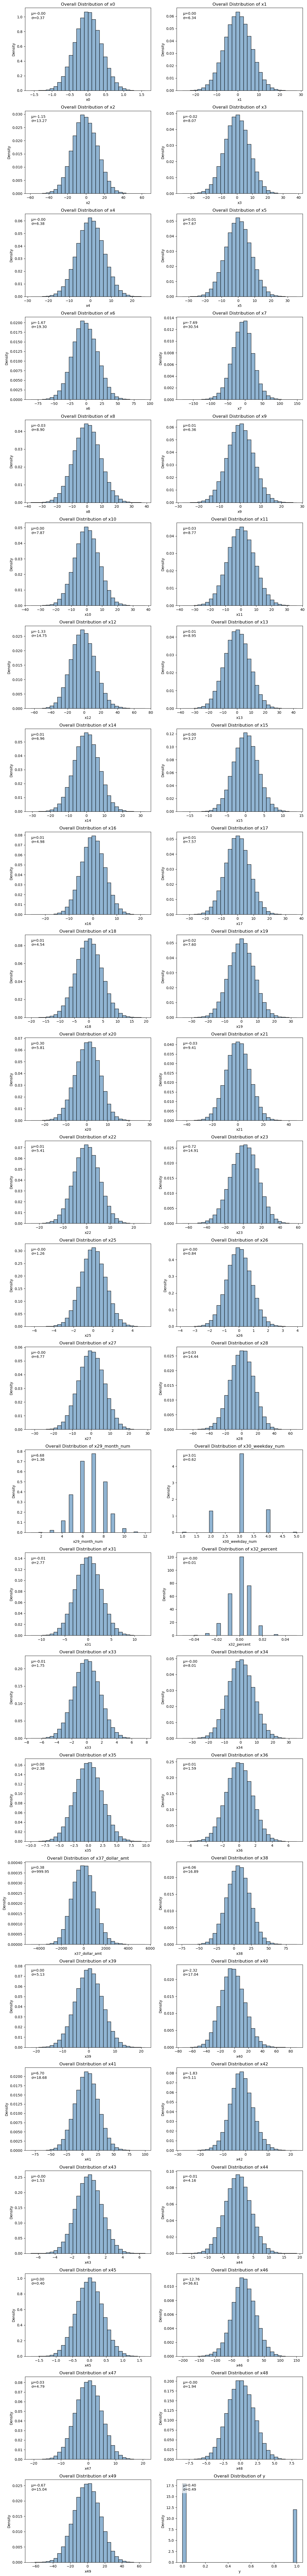

In [25]:
# Prepare for plotting
plot_features_df = clean_data.copy()
# plot_features_df = plot_features_df.drop(columns='# label')
cols_to_plot = num_cols

n_cols = 2
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    data = plot_features_df[col]
    mean = data.mean()
    std = data.std()

    sns.histplot(data=plot_features_df, x=col, bins=30, stat='density',
                 color='steelblue', alpha=0.6, ax=ax)

    ax.text(0.05, 0.95, f"μ={mean:.2f}\nσ={std:.2f}",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='white', alpha=0.7))

    ax.set_title(f"Overall Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

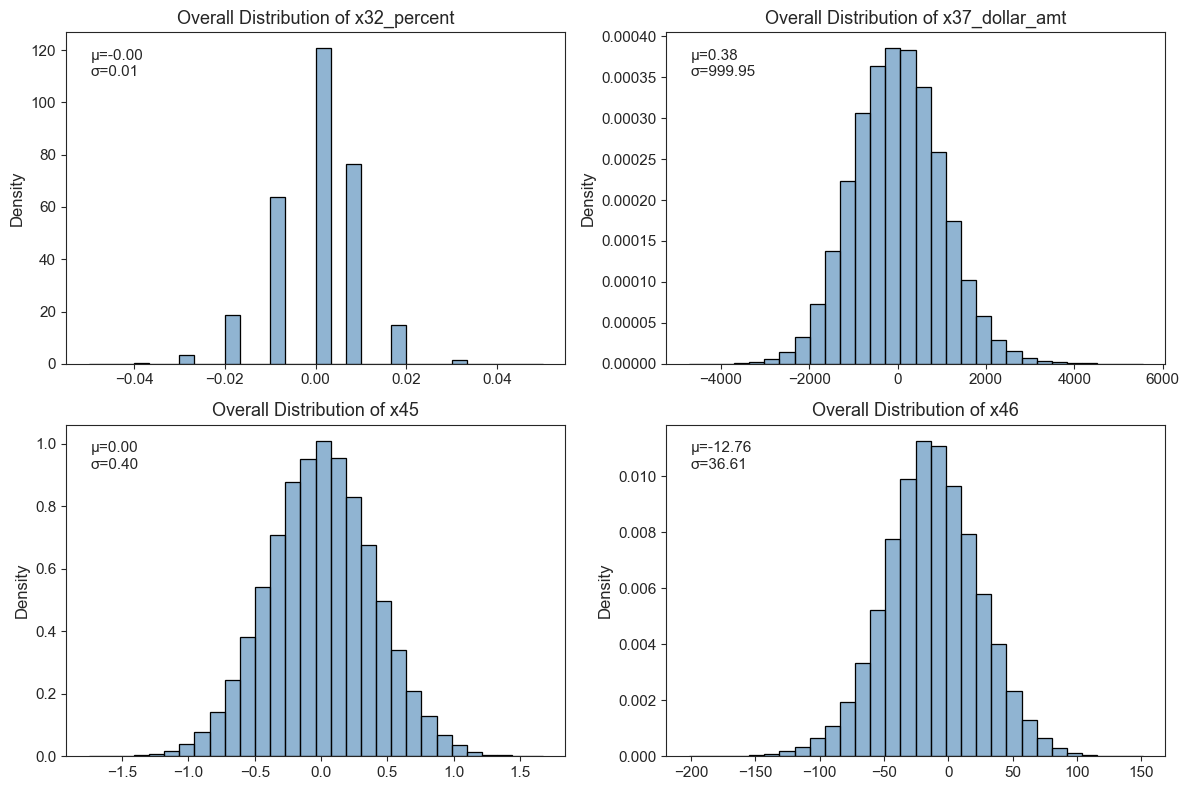

In [229]:
sns.set_style("ticks")

# Prepare for plotting
plot_features_df = clean_data.copy()
# plot_features_df = plot_features_df.drop(columns='# label')
cols_to_plot = ['x32_percent', 'x37_dollar_amt', 'x45', 'x46']

n_cols = 2
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

# Plot each histogram
for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    data = plot_features_df[col]
    mean = data.mean()
    std = data.std()

    sns.histplot(data=plot_features_df, x=col, bins=30, stat='density',
                 color='steelblue', edgecolor='black', alpha=0.6, ax=ax)

    ax.text(0.05, 0.95, f"μ={mean:.2f}\nσ={std:.2f}",
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='white', alpha=0.7))

    ax.set_title(f"Overall Distribution of {col}", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("Density", fontsize=12)
    ax.tick_params(axis='both', labelsize=11)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

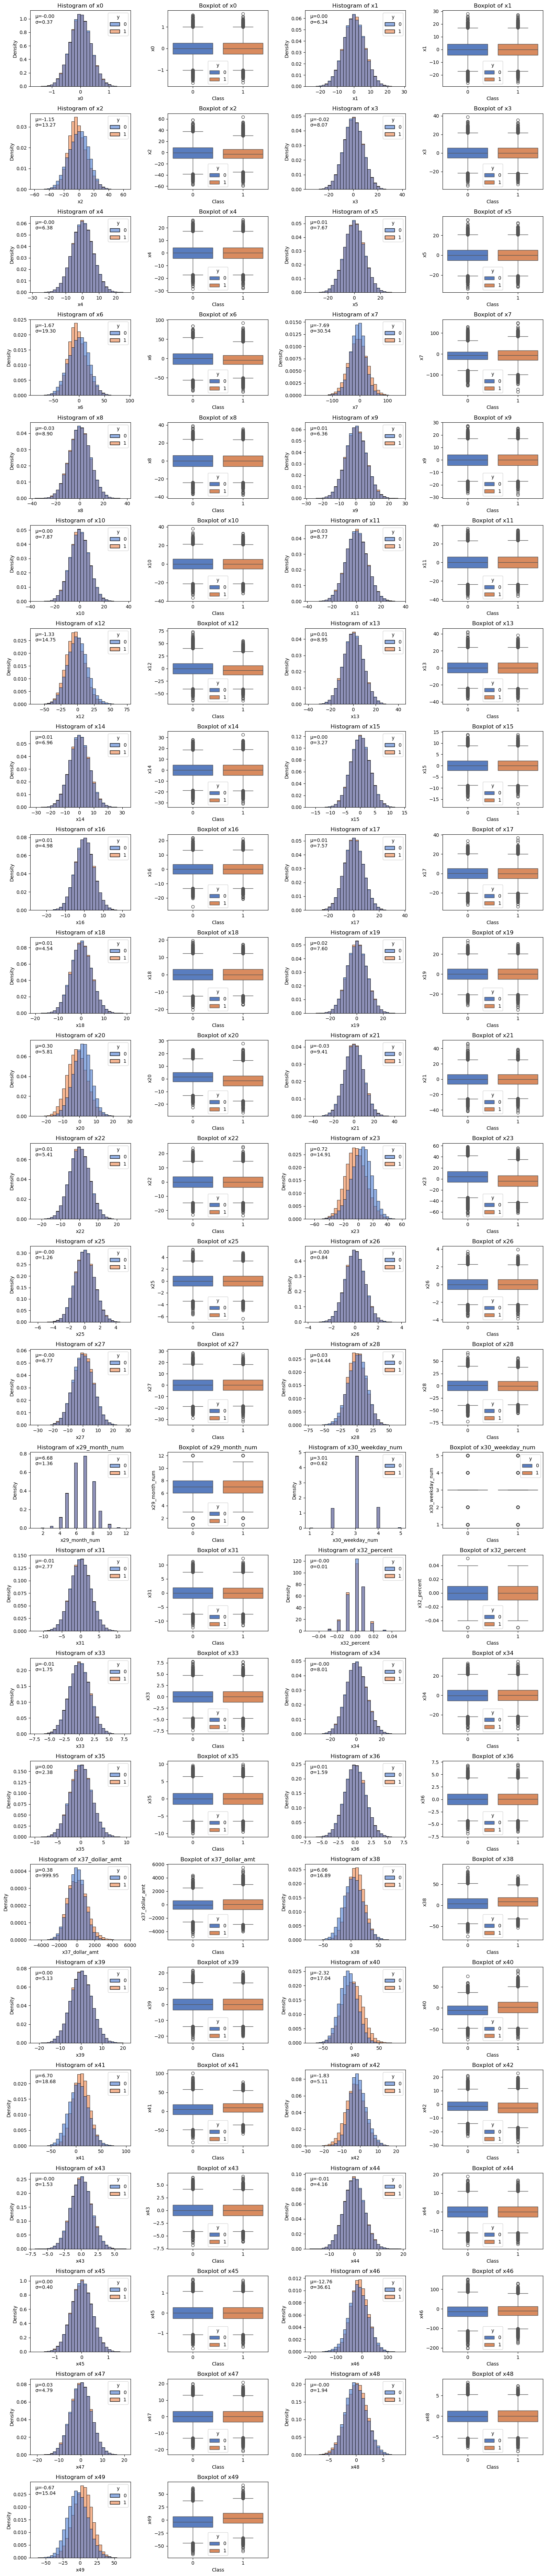

In [27]:
# Prepare data
plot_features_df = clean_data.copy()
cols_to_plot = plot_features_df.drop(columns=['y']).select_dtypes(include='number').columns

# Setup: 2 plots (hist + box) per feature, laid out in 4 columns
n_features = len(cols_to_plot)
plots_per_row = 4  # 2 features per row (each with 2 plots)
n_rows = int(np.ceil(n_features / 2))
fig, axes = plt.subplots(n_rows, plots_per_row, figsize=(16, 3 * n_rows))
axes = axes.reshape(n_rows, plots_per_row)

# Set color palette
classes = plot_features_df['y'].unique()
palette = sns.color_palette("muted", n_colors=len(classes))

for i, col in enumerate(cols_to_plot):
    row = i // 2
    col_offset = (i % 2) * 2  # 0 or 2: position within the row

    # Histogram
    ax_hist = axes[row, col_offset]
    sns.histplot(
        data=plot_features_df,
        x=col,
        hue='y',
        bins=30,
        stat='density',
        common_norm=False,
        palette=palette,
        alpha=0.6,
        ax=ax_hist
    )

    # Conditional legend
    handles, labels = ax_hist.get_legend_handles_labels()
    if labels:
        ax_hist.legend(title="y")

    mean = plot_features_df[col].mean()
    std = plot_features_df[col].std()
    ax_hist.text(0.05, 0.95, f"μ={mean:.2f}\nσ={std:.2f}",
                 transform=ax_hist.transAxes, fontsize=10, va='top',
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='white', alpha=0.7))

    ax_hist.set_title(f"Histogram of {col}")
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel("Density")

    # Boxplot
    ax_box = axes[row, col_offset + 1]
    sns.boxplot(
        data=plot_features_df,
        x='y',
        y=col,
        palette=palette,
        ax=ax_box,
        hue='y'
    )

    ax_box.set_title(f"Boxplot of {col}")
    ax_box.set_xlabel("Class")
    ax_box.set_ylabel(col)

# Hide unused axes (if odd number of features)
for j in range(i + 1, n_rows * 2):
    row = j // 2
    col_offset = (j % 2) * 2
    for k in range(2):
        fig.delaxes(axes[row, col_offset + k])

plt.tight_layout()
plt.show()


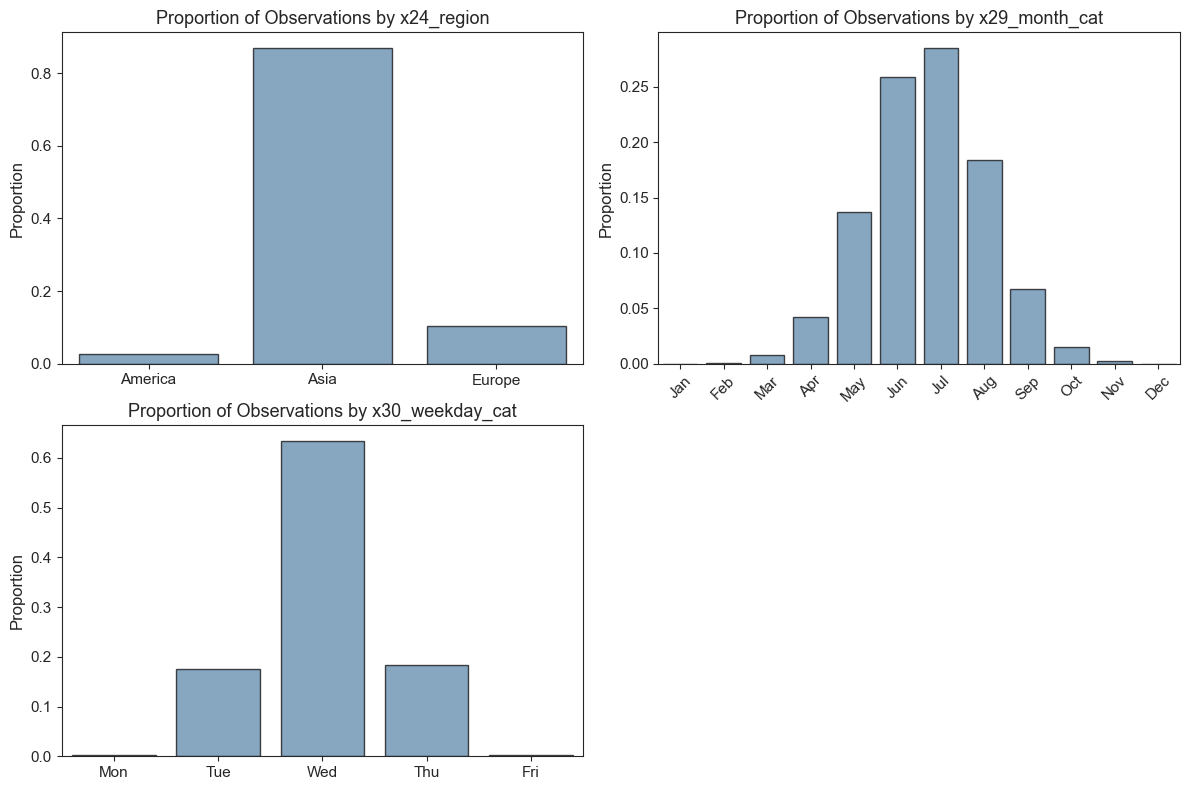

In [231]:
# Prepare for plotting
plot_features_df = clean_data.copy()
cols_to_plot = ['x24_region', 'x29_month_cat', 'x30_weekday_cat']

# Define custom order for each column
custom_orders = {
    'x24_region': ['America', 'Asia', 'Europe'],
    'x29_month_cat': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'x30_weekday_cat': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
}

n_cols = 2
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    order = custom_orders.get(col, plot_features_df[col].value_counts().index)
    
    # Calculate proportions and counts
    counts = plot_features_df[col].value_counts().reindex(order)
    proportions = counts / counts.sum()

    # Create plotting DataFrame
    plot_df = pd.DataFrame({
        col: order,
        'proportion': proportions.values,
        'count': counts.values
    })

    # Plot bar graph of proportions
    sns.barplot(data=plot_df, x=col, y='proportion',
                order=order, color='steelblue', edgecolor='black', alpha=0.7, ax=ax)

    ax.set_title(f"Proportion of Observations by {col}", fontsize=13)
    ax.set_xlabel("")  # no label
    ax.set_ylabel("Proportion", fontsize=12)
    ax.tick_params(axis='both', labelsize=11)

    # Rotate x-axis labels if many categories
    if len(order) > 5:
        ax.tick_params(axis='x', rotation=45)

    # # Add annotations
    # threshold = 0.05
    # for j, bar in enumerate(ax.patches):
    #     height = bar.get_height()
    #     pct = plot_df['proportion'].iloc[j] * 100

    #     if height > threshold:
    #         ax.text(bar.get_x() + bar.get_width() / 2, height / 2,
    #                 f"{pct:.2f}%", ha='center', va='center', fontsize=10)
    #     else:
    #         ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
    #                 f"{pct:.2f}%", ha='center', va='bottom', fontsize=10)

    # if ax.get_legend():
    #     ax.get_legend().remove()

# Hide unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



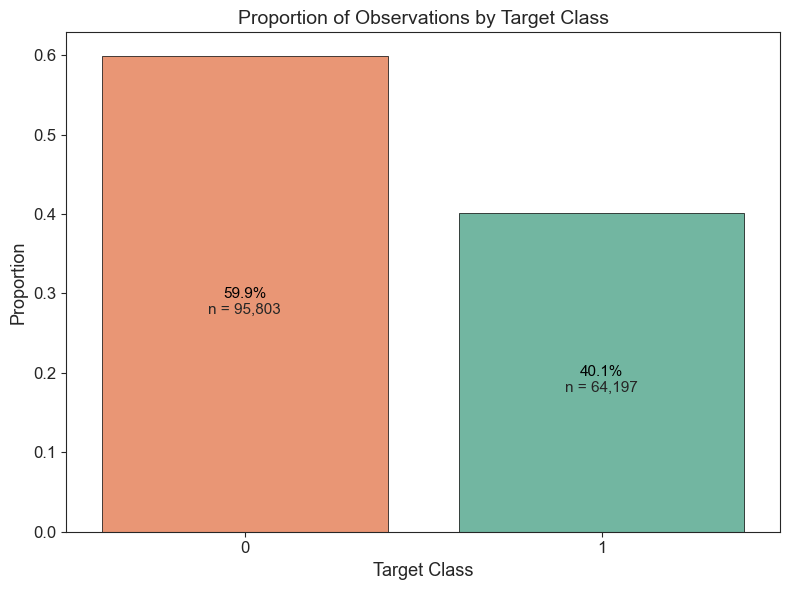

In [238]:
# Set the color palette
palette = sns.color_palette("Set2", n_colors=len(clean_data['y'].unique()))[::-1]

# Calculate counts and proportions of each category
class_counts = clean_data['y'].value_counts(sort=False)  # Counts
class_proportions = class_counts / class_counts.sum()  # Proportions

# label_map = {0: 'neg class', 1: 'pos class'}

# Create a DataFrame for plotting with proper labels
plot_df = pd.DataFrame({
    'class_label': class_counts.index,  #.map(label_map),
    'proportion': class_proportions.values,
    'count': class_counts.values
})

# Plot the distribution
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    x='class_label',
    y='proportion',
    data=plot_df,
    palette=palette,
    hue='class_label',
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)

# Remove the legend (redundant with x-axis labels)
ax.get_legend().remove() if ax.get_legend() else None

# Add titles and labels with larger font sizes
ax.set_title('Proportion of Observations by Target Class', fontsize=14)
ax.set_xlabel('Target Class', fontsize=13)
ax.set_ylabel('Proportion', fontsize=13)

# Optional: increase tick label font size too
ax.tick_params(axis='both', labelsize=12)

# Threshold below which the label will be placed *above* the bar
threshold = 0.05  # Adjust as needed based on your data

for i, (bar, count) in enumerate(zip(ax.patches, plot_df['count'])):
    height = bar.get_height()
    percentage = plot_df['proportion'].iloc[i] * 100

    # Percentage label: inside if tall enough, else above
    if height > threshold:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{percentage:.1f}%',
            ha='center', va='center',
            fontsize=11,
            color='black'
        )
            # Count label on top
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2 - 0.02,
            f'n = {count:,}',
            ha='center', va='center',
            fontsize=11
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.025,
            f'{percentage:.1f}%',
            ha='center', va='bottom',
            fontsize=11,
            color='black'
        )
            # Count label on top
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'n = {count:,}',
            ha='center', va='bottom',
            fontsize=11
        )

plt.tight_layout()
plt.show()

In [30]:
# Select only numeric columns (excluding 'y')
numeric_cols = clean_data.select_dtypes(include='number').drop(columns='y')

# Compute correlation of each feature with y
cor_with_y = clean_data[numeric_cols.columns].corrwith(clean_data['y'])

# Convert to table format
cor_table = cor_with_y.to_frame(name='Correlation with y').sort_values(by='Correlation with y', ascending=False)
print(cor_table)

                 Correlation with y
x49                        0.222267
x40                        0.191994
x41                        0.122865
x38                        0.122771
x37_dollar_amt             0.055002
x46                        0.040832
x7                         0.014935
x34                        0.004963
x16                        0.004341
x27                        0.003681
x9                         0.003286
x1                         0.003056
x21                        0.003012
x18                        0.002723
x25                        0.001787
x19                        0.001744
x0                         0.001545
x3                         0.001533
x36                        0.001091
x5                         0.000985
x28                        0.000953
x11                        0.000670
x4                         0.000608
x43                        0.000279
x44                        0.000204
x47                       -0.000106
x22                       -0

In [31]:
# Compute full correlation matrix (absolute values to find strength)
corr_matrix = clean_data.select_dtypes(include='number').corr().abs()

# Unstack to long format
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = corr_pairs.stack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Sort and show top N
top_corrs = corr_pairs.sort_values(by='Correlation', ascending=False)
print(top_corrs.head(20))  # or .to_markdown() if you want Markdown table

# # Filter for correlations above 0.3
# strong_corrs = corr_pairs[corr_pairs['Correlation'] > 0.3]

# # Sort and show
# strong_corrs = strong_corrs.sort_values(by='Correlation', ascending=False)
# print(strong_corrs)

           Feature 1       Feature 2  Correlation
1149             x38             x41     1.000000
100               x2              x6     1.000000
130               x2  x37_dollar_amt     0.726629
308               x6  x37_dollar_amt     0.726627
889              x23             x40     0.651918
340               x7             x27     0.570490
808              x20             x40     0.505065
1137  x37_dollar_amt             x41     0.493519
1134  x37_dollar_amt             x38     0.493457
353               x7             x40     0.489434
1217             x46             x49     0.487731
351               x7             x38     0.486413
354               x7             x41     0.486345
554              x12             x46     0.485462
805              x20  x37_dollar_amt     0.471394
1192             x42             x46     0.452964
1142  x37_dollar_amt             x46     0.440942
980              x28  x37_dollar_amt     0.433083
548              x12             x40     0.421681


In [32]:
# Which of the pair is the more correlated with the target
print(clean_data[['x38', 'x41']].corrwith(clean_data['y']))
print(clean_data[['x2', 'x6']].corrwith(clean_data['y']))

# See how many missing values
print("Missing counts:")
print("x38:", clean_data['x38'].isna().sum())
print("x41:", clean_data['x41'].isna().sum())
print("x2:", clean_data['x2'].isna().sum())
print("x6:", clean_data['x6'].isna().sum())

# Get index sets
missing_x38 = set(clean_data.index[clean_data['x38'].isna()])
missing_x41 = set(clean_data.index[clean_data['x41'].isna()])
missing_x2 = set(clean_data.index[clean_data['x2'].isna()])
missing_x6 = set(clean_data.index[clean_data['x6'].isna()])

# Pairwise intersections
x38_x41_overlap = missing_x38 & missing_x41
x2_x6_overlap = missing_x2 & missing_x6

# Print results
print(f"Missing in both x38 and x41: {len(x38_x41_overlap)} rows")
print(sorted(x38_x41_overlap))  # optional: display actual row numbers

print(f"Missing in both x2 and x6: {len(x2_x6_overlap)} rows")
print(sorted(x2_x6_overlap))

# (Optional) Differences
print(f"Missing in x38 only: {len(missing_x38 - missing_x41)}")
print(f"Missing in x41 only: {len(missing_x41 - missing_x38)}")

print(f"Missing in x2 only: {len(missing_x2 - missing_x6)}")
print(f"Missing in x6 only: {len(missing_x6 - missing_x2)}")


x38    0.122771
x41    0.122865
dtype: float64
x2   -0.050527
x6   -0.050504
dtype: float64
Missing counts:
x38: 31
x41: 40
x2: 38
x6: 26
Missing in both x38 and x41: 0 rows
[]
Missing in both x2 and x6: 0 rows
[]
Missing in x38 only: 31
Missing in x41 only: 40
Missing in x2 only: 38
Missing in x6 only: 26


- Features x38 and x41 are perfectly correlated as are features x2 and x6.
- x41 and x2 are ever so slightly more correlated with the target variable so I will keep them and drop x38 and x6.
- However, x41 and x2 have more slightly more missing values than the columns I'm dropping.
- There is no overlap in the missing rows between the pairs so I can use the perfect correlation to impute the missing values.

### Imputation

In [33]:
# Make a copy of the clean_data dataset
imputed_data = clean_data.copy()
print(imputed_data.columns)
print(imputed_data.shape)

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20',
       'x21', 'x22', 'x23', 'x24_region', 'x25', 'x26', 'x27', 'x28',
       'x29_month_cat', 'x29_month_num', 'x30_weekday_cat', 'x30_weekday_num',
       'x31', 'x32_percent', 'x33', 'x34', 'x35', 'x36', 'x37_dollar_amt',
       'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47',
       'x48', 'x49', 'y'],
      dtype='object')
(160000, 53)


In [34]:
# Check the linear relationship between the pairs

# Drop rows with missing and return the indexes of the non-missings
mask = imputed_data[['x38', 'x41']].dropna().index
# Select the masked rows for the predictor (being dropped)
X = imputed_data.loc[mask, ['x38']]
# Select the masked rows for the target (being kept)
y = imputed_data.loc[mask, 'x41']

# Fit a linear model 
model41 = LinearRegression().fit(X, y)
# View the linear relationship
print(f"x41 ≈ {model41.coef_[0]:.4f} * x38 + {model41.intercept_:.4f}")

x41 ≈ 1.1059 * x38 + 0.0000


In [35]:
# Impute missing x41 using fitted model from x38

# Get the rows that are missing in x41 but not in x38
mask = imputed_data['x41'].isna() & imputed_data['x38'].notna()
# Fill the x41 masked rows with predictions from fitted model
imputed_data.loc[mask, 'x41'] = model41.predict(imputed_data.loc[mask, ['x38']])

In [36]:
# Check the linear relationship between the pairs

# Drop rows with missing and return the indexes of the non-missings
mask = imputed_data[['x2', 'x6']].dropna().index
# Select the masked rows for the predictor (being dropped)
X = imputed_data.loc[mask, ['x6']]
# Select the masked rows for the target (being kept)
y = imputed_data.loc[mask, 'x2']

# Fit a linear model 
model2 = LinearRegression().fit(X, y)
# View the linear relationship
print(f"x2 ≈ {model2.coef_[0]:.4f} * x6 + {model2.intercept_:.4f}")

x2 ≈ 0.6878 * x6 + -0.0000


In [37]:
# Impute missing x2 using fitted model from x6

# Get the rows that are missing in x2 but not in x6
mask = imputed_data['x2'].isna() & imputed_data['x6'].notna()
# Fill the x2 masked rows with predictions from fitted model
imputed_data.loc[mask, 'x2'] = model2.predict(imputed_data.loc[mask, ['x6']])

In [38]:
# Sanity check
# See how many missing values
print("Missing counts:")
print("x41:", imputed_data['x41'].isna().sum())
print("x2:", imputed_data['x2'].isna().sum())


Missing counts:
x41: 0
x2: 0


In [39]:
imputed_data.shape

(160000, 53)

In [40]:
imputed_data = imputed_data.drop(columns=['x6', 'x38'])
print(imputed_data.columns)
print(imputed_data.shape)

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x7', 'x8', 'x9', 'x10', 'x11',
       'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21',
       'x22', 'x23', 'x24_region', 'x25', 'x26', 'x27', 'x28', 'x29_month_cat',
       'x29_month_num', 'x30_weekday_cat', 'x30_weekday_num', 'x31',
       'x32_percent', 'x33', 'x34', 'x35', 'x36', 'x37_dollar_amt', 'x39',
       'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49',
       'y'],
      dtype='object')
(160000, 51)


- For simplicity since each column is missinge fewer than 0.03% of values, I am going to impute the categorical variables with the mode. I will convert those categories into their numeric values for the month and weekday (even though it is probably the same to impute the median for the numeric).
- For the percentages, since I originally converted these from object variables to numeric and because they are discrete, it would make more sense to impute with the mode rather than the median. However the mode and the median are both 0.
- For the remaining numeric variables I will impute the median value for the column.

In [41]:
imputed_data['x24_region'].mode()[0]

'Asia'

In [42]:
imputed_data['x24_region'].value_counts()

x24_region
Asia       138965
Europe      16538
America      4469
Name: count, dtype: int64

In [43]:
imputed_data['x24_region'].isna().sum()

28

In [44]:
# Impute missing x24_region with the mode
mode_region = imputed_data['x24_region'].mode()[0]
imputed_data['x24_region'] = imputed_data['x24_region'].fillna(mode_region)
print(imputed_data['x24_region'].isna().sum())

0


In [45]:
imputed_data['x29_month_cat'].mode()[0]

'Jul'

In [46]:
print(imputed_data['x29_month_cat'].isna().sum())
print(imputed_data['x29_month_num'].isna().sum())
print(imputed_data.index[imputed_data['x29_month_cat'].isna()][0])

30
30
126


In [47]:
print(imputed_data['x29_month_cat'][126])

nan


In [48]:
# Impute missing month_cat with the mode
mode_month = imputed_data['x29_month_cat'].mode()[0]
imputed_data['x29_month_cat'] = imputed_data['x29_month_cat'].fillna(mode_month)

# Recompute month_num from the updated month_cat
codes = imputed_data['x29_month_cat'].cat.codes
imputed_data['x29_month_num'] = (codes.replace(-1, pd.NA) + 1).astype('Int64')

# Sanity check
print(imputed_data['x29_month_cat'].isna().sum())
print(imputed_data['x29_month_num'].isna().sum())
print(imputed_data['x29_month_cat'][126])
print(imputed_data['x29_month_num'][126])

0
0
Jul
7


In [49]:
imputed_data['x30_weekday_cat'].mode()[0]

'Wed'

In [50]:
print(imputed_data['x30_weekday_cat'].isna().sum())
print(imputed_data['x30_weekday_num'].isna().sum())
print(imputed_data.index[imputed_data['x30_weekday_cat'].isna()][0])

30
30
3445


In [51]:
print(imputed_data['x30_weekday_cat'][3445])

nan


In [52]:
# Impute missing weekday_cat with the mode
mode_month = imputed_data['x30_weekday_cat'].mode()[0]
imputed_data['x30_weekday_cat'] = imputed_data['x30_weekday_cat'].fillna(mode_month)

# Recompute weekday_num from the updated weekday_cat
codes = imputed_data['x30_weekday_cat'].cat.codes
imputed_data['x30_weekday_num'] = (codes.replace(-1, pd.NA) + 1).astype('Int64')

# Sanity check
print(imputed_data['x30_weekday_cat'].isna().sum())
print(imputed_data['x30_weekday_num'].isna().sum())
print(imputed_data['x30_weekday_cat'][3445])
print(imputed_data['x30_weekday_num'][3445])

0
0
Wed
3


In [53]:
imputed_data.isna().sum()

x0                 26
x1                 25
x2                  0
x3                 37
x4                 26
x5                 37
x7                 27
x8                 21
x9                 30
x10                43
x11                30
x12                36
x13                31
x14                34
x15                35
x16                26
x17                27
x18                40
x19                35
x20                38
x21                29
x22                27
x23                47
x24_region          0
x25                22
x26                36
x27                30
x28                35
x29_month_cat       0
x29_month_num       0
x30_weekday_cat     0
x30_weekday_num     0
x31                39
x32_percent        31
x33                41
x34                41
x35                30
x36                27
x37_dollar_amt     23
x39                23
x40                36
x41                 0
x42                26
x43                37
x44                40
x45       

In [54]:
# Checking for percent mode and median to decide on an imputation strategy.
print(imputed_data['x32_percent'].mode()[0])
print(imputed_data['x32_percent'].median())

0.0
0.0


In [55]:
# Helper function to impute the remaining numeric columns with missings with their median values.
def impute_numeric_with_median(df, num_cols):
    """
    Impute numeric columns with median and track which columns were imputed.

    Parameters:
        df (pd.DataFrame): Your DataFrame.
        num_cols (list): List of numeric column names to impute.

    Returns:
        df (pd.DataFrame): Updated DataFrame with imputed values.
        imputed_log (dict): Dict showing column: (median, count of values imputed)
    """
    imputed_log = {}

    for col in num_cols:
        if df[col].isna().any():
            median_val = df[col].median()
            missing_count = df[col].isna().sum()
            df[col] = df[col].fillna(median_val)
            imputed_log[col] = (median_val, missing_count)

    return df, imputed_log


In [56]:
# Identify numeric columns
numeric_cols = imputed_data.select_dtypes(include='number').columns.tolist()

# Impute and track
imputed_data, numeric_impute_log = impute_numeric_with_median(imputed_data, numeric_cols)

# Review imputation log
for col, (med, count) in numeric_impute_log.items():
    print(f"{col}: filled {count} missing with median = {med}")


x0: filled 26 missing with median = -0.00204727135035655
x1: filled 25 missing with median = 0.0048127284918881
x3: filled 37 missing with median = -0.0314081183575717
x4: filled 26 missing with median = 0.00085673010305925
x5: filled 37 missing with median = 0.0141178141428364
x7: filled 27 missing with median = -6.956788886630686
x8: filled 21 missing with median = -0.0168400599325282
x9: filled 30 missing with median = 0.00604511957773105
x10: filled 43 missing with median = -0.0181764302111621
x11: filled 30 missing with median = 0.0109405929566091
x12: filled 36 missing with median = -1.6244390921824505
x13: filled 31 missing with median = -0.0034731251113515
x14: filled 34 missing with median = 0.00246711229149175
x15: filled 35 missing with median = 0.0035353270757401
x16: filled 26 missing with median = 0.01275418529804845
x17: filled 27 missing with median = 0.0245405647868615
x18: filled 40 missing with median = 0.015903618605164
x19: filled 35 missing with median = 0.0447027

In [57]:
print(imputed_data.isna().sum()[imputed_data.isna().sum() > 0])

Series([], dtype: int64)


In [58]:
imputed_data.columns

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x7', 'x8', 'x9', 'x10', 'x11',
       'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21',
       'x22', 'x23', 'x24_region', 'x25', 'x26', 'x27', 'x28', 'x29_month_cat',
       'x29_month_num', 'x30_weekday_cat', 'x30_weekday_num', 'x31',
       'x32_percent', 'x33', 'x34', 'x35', 'x36', 'x37_dollar_amt', 'x39',
       'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49',
       'y'],
      dtype='object')

In [59]:
pd.crosstab(imputed_data['x29_month_cat'], imputed_data['y'], normalize='index')

y,0,1
x29_month_cat,,
Jan,0.666667,0.333333
Feb,0.614286,0.385714
Mar,0.604387,0.395613
Apr,0.594143,0.405857
May,0.595424,0.404576
Jun,0.599143,0.400857
Jul,0.600693,0.399307
Aug,0.599129,0.400871
Sep,0.600240,0.399760


Because there's a monotonic increase in the positive class proportion across the months, the order of months is meaningful for prediction. That means:
- Month is acting like a continuous or ordered predictor, not a purely categorical one.
- Using integers 1–12 preserves this natural ordering.
- Tree-based models can leverage these order relationships through split points like month ≤ 6.

In [60]:
pd.crosstab(imputed_data['x30_weekday_cat'], imputed_data['y'], normalize='index')

y,0,1
x30_weekday_cat,,
Mon,0.600410,0.399590
Tue,0.600093,0.399907
Wed,0.597381,0.402619
Thu,0.601991,0.398009
Fri,0.613475,0.386525


Because the positive class proportion is nearly constant across the weekdays, the order of days does not carry meaningful predictive information. That means:
- Day of the week behaves like a nominal (unordered) categorical variable, not an ordinal or continuous one.
- While Random Forest requires numeric input, using an integer encoding (e.g., Mon = 0, Tue = 1, …) is acceptable as long as the model does not assume the numeric order implies anything about distance.
- Random Forest can handle these integer-encoded labels without interpreting them as ordered, since trees split by threshold rather than compute distance or trend.

## Random Forest (Baseline Model)

### Data and Feature Setup

In [61]:
X = imputed_data.drop(columns=['y', 'x29_month_cat', 'x30_weekday_cat'])
print(X.head())
print(X.columns)
y = imputed_data['y'] 
print(y.head())

         x0        x1         x2        x3        x4         x5         x7  \
0 -0.166563 -3.961588   4.621113  2.481908 -1.800135   0.804684 -14.789997   
1 -0.149894 -0.585676  27.839856  4.152333  6.426802  -2.426943  -6.725709   
2 -0.321707 -1.429819  12.251561  6.586874 -5.304647 -11.311090  11.060572   
3 -0.245594  5.076677 -24.149632  3.637307  6.505811   2.290224 -18.913592   
4 -0.273366  0.306326 -11.352593  1.676758  2.928441  -0.616824  27.532281   

         x8        x9        x10  ...        x40        x41       x42  \
0 -1.040673 -4.204950   6.187465  ... -10.612200  -1.497117  5.414063   
1  0.896421  0.330165 -11.708859  ...   2.147427  36.292790  4.490915   
2  5.325880 -2.632984   1.572647  ...  -0.863137  -0.368491  9.088864   
3 -0.337041 -5.568076  -2.000255  ...  12.084421  15.691546 -7.467775   
4  1.199715 -4.309105   6.667530  ...  30.004727 -13.911297 -5.229937   

        x43       x44       x45        x46       x47       x48        x49  
0 -2.325655  1.6

In [62]:
type(X), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

### Preprocessing Pipeline

Need to one-hot-encode region.

In [63]:
# Make a pipeline to One Hot Encode x24_region
# Define columns
region_col = ['x24_region']
numeric_cols = [col for col in X.columns if col not in region_col]

# Preprocessing
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), region_col),
    ('num', 'passthrough', numeric_cols)
])

### Initial Hyperparameter Tuning

In [64]:
# X, y already created
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf = RandomForestClassifier(n_estimators=100, random_state=SEED)  # 100 estimators for tuning

# Full pipeline
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', rf)
])

rf_params = {
    'clf__criterion': ['gini', 'entropy'], 
    'clf__max_depth': [3, 5, 10, 15, 20, 30],
    'clf__max_features': ['sqrt', 0.5],
    'clf__min_samples_leaf': [2, 5, 10, 25], # I made these a bit bigger given the dataset size
    'clf__min_samples_split': [4, 10, 20, 50],
    'clf__class_weight': [None, 'balanced']
}

# Define multiple scorers
scoring = {
    'auc': 'roc_auc',
    # 'fbeta_0.5': make_scorer(fbeta_score, beta=0.5, pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1),
    # 'recall': make_scorer(recall_score, pos_label=1),
    'accuracy': make_scorer(accuracy_score) # just for reference
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_params,
    n_iter=30, cv=cv, 
    scoring=scoring, refit='auc',  # Use AUC to choose best estimator
    verbose=2, n_jobs=-1,
    # verbose=1, n_jobs=10,
    random_state=SEED,
    return_train_score=True
)

# Time hypertuning
start = time.perf_counter()

rf_search.fit(X, y)

end = time.perf_counter()
print(f"Elapsed time for CV RF predictions: {((end - start)/60):.3f} minutes")

print("Best AUC:", rf_search.best_score_)
print("Best Parameters:", rf_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END clf__class_weight=balanced, clf__criterion=entropy, clf__max_depth=3, clf__max_features=sqrt, clf__min_samples_leaf=10, clf__min_samples_split=50; total time=  26.6s
[CV] END clf__class_weight=balanced, clf__criterion=entropy, clf__max_depth=3, clf__max_features=sqrt, clf__min_samples_leaf=10, clf__min_samples_split=50; total time=  26.9s
[CV] END clf__class_weight=balanced, clf__criterion=entropy, clf__max_depth=3, clf__max_features=sqrt, clf__min_samples_leaf=10, clf__min_samples_split=50; total time=  18.9s
[CV] END clf__class_weight=balanced, clf__criterion=entropy, clf__max_depth=3, clf__max_features=sqrt, clf__min_samples_leaf=10, clf__min_samples_split=50; total time=  24.1s
[CV] END clf__class_weight=balanced, clf__criterion=entropy, clf__max_depth=3, clf__max_features=sqrt, clf__min_samples_leaf=10, clf__min_samples_split=50; total time=  19.4s
[CV] END clf__class_weight=balanced, clf__criterion=gini, clf__

### Initial Results Summary

In [65]:
results = pd.DataFrame(rf_search.cv_results_)

# Sort by AUC and view top 5
summary_cols = [
    'mean_test_auc', 
    'mean_test_precision', 
    'mean_test_accuracy',
    'mean_fit_time', 
    'rank_test_auc', 
    'params'
]

top_models = results.sort_values(by='mean_test_auc', ascending=False).head(10)
pd.DataFrame(top_models[summary_cols])

,mean_test_auc,mean_test_precision,mean_test_accuracy,mean_fit_time,rank_test_auc,params
3,0.976130,0.930443,0.924456,93.019664,1,"{'clf__min_samples_split': 4, 'clf__min_sample..."
12,0.975211,0.904709,0.924556,259.048297,2,"{'clf__min_samples_split': 10, 'clf__min_sampl..."
4,0.974908,0.907728,0.923525,92.254678,3,"{'clf__min_samples_split': 20, 'clf__min_sampl..."
19,0.973776,0.905143,0.921487,85.877542,4,"{'clf__min_samples_split': 20, 'clf__min_sampl..."
9,0.973113,0.897777,0.919644,93.456914,5,"{'clf__min_samples_split': 50, 'clf__min_sampl..."
6,0.972691,0.926433,0.917256,82.802347,6,"{'clf__min_samples_split': 4, 'clf__min_sample..."
27,0.972199,0.891574,0.917987,212.164867,7,"{'clf__min_samples_split': 20, 'clf__min_sampl..."
24,0.972002,0.896926,0.918494,84.340460,8,"{'clf__min_samples_split': 50, 'clf__min_sampl..."
17,0.971321,0.925356,0.914669,84.736707,9,"{'clf__min_samples_split': 50, 'clf__min_sampl..."
29,0.970530,0.893110,0.914631,71.305684,10,"{'clf__min_samples_split': 4, 'clf__min_sample..."


In [66]:
top_models

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__min_samples_split,param_clf__min_samples_leaf,param_clf__max_features,param_clf__max_depth,param_clf__criterion,param_clf__class_weight,...,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_train_accuracy,split1_train_accuracy,split2_train_accuracy,split3_train_accuracy,split4_train_accuracy,mean_train_accuracy,std_train_accuracy
3,93.019664,0.670536,1.001558,0.035277,4,5,sqrt,30,entropy,None,...,0.924456,0.002482,2,0.989805,0.989805,0.989844,0.989742,0.990313,0.989902,0.000208
12,259.048297,0.556773,0.805800,0.012699,10,10,0.5,15,gini,balanced,...,0.924556,0.002914,1,0.959984,0.959484,0.959406,0.960164,0.960383,0.959884,0.000381
4,92.254678,0.896553,0.932105,0.014324,20,5,sqrt,20,entropy,balanced,...,0.923525,0.002342,3,0.975094,0.974258,0.975008,0.974602,0.975883,0.974969,0.000546
19,85.877542,0.300432,0.941776,0.011210,20,5,sqrt,20,gini,balanced,...,0.921487,0.002933,4,0.970133,0.971344,0.970719,0.971047,0.971742,0.970997,0.000548
9,93.456914,0.545466,0.907857,0.015570,50,5,sqrt,30,entropy,balanced,...,0.919644,0.002852,5,0.959805,0.959492,0.959969,0.959945,0.960117,0.959866,0.000211
6,82.802347,0.363405,0.940560,0.013063,4,10,sqrt,20,gini,None,...,0.917256,0.002376,8,0.962086,0.962148,0.961984,0.962164,0.963117,0.962300,0.000413
27,212.164867,1.932914,0.598179,0.011080,20,25,0.5,15,gini,balanced,...,0.917987,0.003193,7,0.941523,0.941828,0.941641,0.941945,0.942148,0.941817,0.000221
24,84.340460,0.744002,0.907746,0.013171,50,5,sqrt,30,gini,balanced,...,0.918494,0.003040,6,0.956953,0.956211,0.956484,0.956258,0.956805,0.956542,0.000294
17,84.736707,0.227533,0.875639,0.018689,50,5,sqrt,20,gini,None,...,0.914669,0.002466,9,0.950906,0.950688,0.950844,0.950984,0.951391,0.950962,0.000235
29,71.305684,1.655672,0.716201,0.039190,4,5,sqrt,15,gini,balanced,...,0.914631,0.002828,10,0.956000,0.955453,0.955328,0.955859,0.956523,0.955833,0.000425


Top initial model: 

- auc: 0.976130
- precision: 0.930443
- test accuracy: 0.924456
- train accuracy: 0.989902
- fit time: 91.288280
- params: min_samples_split=4, min_samples_leaf=5, max_features=sqrt, max_depth=30, criterion=entropy, class_weight=None	

The best models seem to be have params in these ranges:

min_samples_split=[4,10,20], min_samples_leaf=[5,10], max_features=sqrt, max_depth=[15,20,30], criterion=[entropy,gini], class_weight=balanced
(actually 4 min_samples_split doesn't make sense with min_samples_leaf=[5,10])

### Refined Randomized Search (Focused Tuning)

In [67]:
# Refine the grid
rf_params_refined = {
    'clf__criterion': ['gini', 'entropy'], # unsure about these, probably either is fine
    'clf__max_depth': [15, 20, 25, 30, 35], # focus on deeper trees (add 35)
    'clf__max_features': ['sqrt'], # sqrt seems to work
    'clf__min_samples_leaf': [5, 7, 10], # add a mid value given 5 and 10 work best
    'clf__min_samples_split': [4, 10, 20, 30], # add a value larger than 20 but not 50
    'clf__class_weight': ['balanced'] # seems best
}

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_params_refined,
    n_iter=20, cv=cv, 
    scoring=scoring, refit='auc',
    verbose=2, n_jobs=-1,
    random_state=SEED,
    return_train_score=True
)

# Time hypertuning
start = time.perf_counter()

rf_search.fit(X, y)

end = time.perf_counter()
print(f"Elapsed time for CV RF predictions: {((end - start)/60):.3f} minutes")

print("Best AUC:", rf_search.best_score_)
print("Best Parameters:", rf_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=20, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=30; total time= 1.4min
[CV] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=20, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=30; total time= 1.4min
[CV] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=35, clf__max_features=sqrt, clf__min_samples_leaf=7, clf__min_samples_split=10; total time= 1.4min
[CV] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=20, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=30; total time= 1.4min
[CV] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=20, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=30; total time= 1.4min
[CV] END clf__class_weight=balanced, clf__criterion=gini, clf__max_depth=35, c

### Refined Results Summary

In [68]:
results = pd.DataFrame(rf_search.cv_results_)

# Sort by AUC and view top 5
summary_cols = [
    'mean_test_auc', 
    'mean_test_precision', 
    'mean_test_accuracy',
    'mean_fit_time', 
    'rank_test_auc', 
    'params'
]

top_models = results.sort_values(by='mean_test_auc', ascending=False).head(10)
pd.DataFrame(top_models[summary_cols])


,mean_test_auc,mean_test_precision,mean_test_accuracy,mean_fit_time,rank_test_auc,params
11,0.976064,0.916400,0.925450,93.738400,1,"{'clf__min_samples_split': 4, 'clf__min_sample..."
6,0.975332,0.912148,0.924119,93.167872,2,"{'clf__min_samples_split': 4, 'clf__min_sample..."
12,0.974895,0.908983,0.923481,90.284604,3,"{'clf__min_samples_split': 20, 'clf__min_sampl..."
3,0.974459,0.905684,0.922569,92.941479,4,"{'clf__min_samples_split': 20, 'clf__min_sampl..."
2,0.974417,0.906203,0.922875,91.788853,5,"{'clf__min_samples_split': 20, 'clf__min_sampl..."
16,0.974314,0.904667,0.921731,89.598084,6,"{'clf__min_samples_split': 4, 'clf__min_sample..."
0,0.974244,0.909534,0.922781,83.614418,7,"{'clf__min_samples_split': 10, 'clf__min_sampl..."
15,0.974209,0.909891,0.922531,83.232613,8,"{'clf__min_samples_split': 4, 'clf__min_sample..."
5,0.973840,0.905796,0.921869,85.089666,9,"{'clf__min_samples_split': 20, 'clf__min_sampl..."
9,0.973776,0.905143,0.921487,84.772711,10,"{'clf__min_samples_split': 20, 'clf__min_sampl..."


In [69]:
top_models

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__min_samples_split,param_clf__min_samples_leaf,param_clf__max_features,param_clf__max_depth,param_clf__criterion,param_clf__class_weight,...,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_train_accuracy,split1_train_accuracy,split2_train_accuracy,split3_train_accuracy,split4_train_accuracy,mean_train_accuracy,std_train_accuracy
11,93.738400,0.741637,0.977763,0.007530,4,5,sqrt,25,entropy,balanced,...,0.925450,0.003116,1,0.990422,0.990281,0.990141,0.990047,0.990367,0.990252,0.000140
6,93.167872,0.330773,0.967271,0.024867,4,5,sqrt,20,entropy,balanced,...,0.924119,0.002509,2,0.984352,0.983906,0.983625,0.983719,0.984500,0.984020,0.000346
12,90.284604,0.829445,0.941041,0.016649,20,7,sqrt,35,entropy,balanced,...,0.923481,0.002782,3,0.978102,0.978320,0.977773,0.977914,0.978773,0.978177,0.000350
3,92.941479,0.580165,0.957917,0.033162,20,10,sqrt,35,entropy,balanced,...,0.922569,0.002867,6,0.973758,0.973617,0.973727,0.973719,0.974313,0.973827,0.000248
2,91.788853,1.472082,0.963534,0.017040,20,10,sqrt,30,entropy,balanced,...,0.922875,0.002695,4,0.973648,0.973414,0.973555,0.973727,0.974523,0.973773,0.000389
16,89.598084,0.772493,0.914303,0.014051,4,10,sqrt,25,entropy,balanced,...,0.921731,0.003312,9,0.973109,0.972883,0.973047,0.973133,0.973523,0.973139,0.000211
0,83.614418,0.544373,1.051352,0.012877,10,7,sqrt,35,gini,balanced,...,0.922781,0.002906,5,0.977898,0.978250,0.977789,0.978141,0.978375,0.978091,0.000218
15,83.232613,0.437957,0.967540,0.011867,4,5,sqrt,20,gini,balanced,...,0.922531,0.002845,7,0.979844,0.980219,0.980062,0.979852,0.980672,0.980130,0.000305
5,85.089666,0.594015,0.986009,0.039136,20,7,sqrt,30,gini,balanced,...,0.921869,0.003210,8,0.972555,0.972703,0.972594,0.972742,0.972844,0.972687,0.000104
9,84.772711,0.444926,0.941763,0.013676,20,5,sqrt,20,gini,balanced,...,0.921487,0.002933,10,0.970133,0.971344,0.970719,0.971047,0.971742,0.970997,0.000548


Top refined model: 

- auc: 0.976064 (was 0.976130)
- precision: 0.916400 (was 0.930443)
- test accuracy: 0.925450 (was 0.924456)
- train accuracy: 0.990252 (was 0.989902)
- fit time: 92.463936 (was 91.288280)
- params: min_samples_split=4, min_samples_leaf=5, max_features=sqrt, max_depth=25, criterion=entropy, class_weight=balanced
  - params were: min_samples_split=4, min_samples_leaf=5, max_features=sqrt, max_depth=30, criterion=entropy, class_weight=None	

The best models seem to be have params:

min_samples_split=[4], min_samples_leaf=[5], max_features=sqrt, max_depth=[25,30], criterion=[entropy], class_weight=[None, balanced]
(actually 4 min_samples_split doesn't make sense with min_samples_leaf=[5,10])

### Final Grid Search Tuning

In [70]:
# Define multiple scorers
scoring = {
    'auc': 'roc_auc',
    # 'fbeta_0.5': make_scorer(fbeta_score, beta=0.5, pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1),
    # 'recall': make_scorer(recall_score, pos_label=1),
    'accuracy': make_scorer(accuracy_score) # just for reference
}

# Grid search instead of randomized search
rf_search = GridSearchCV(
    rf_pipeline,
    param_grid={
        'clf__criterion': ['entropy'],
        'clf__max_depth': [25, 30],
        'clf__max_features': ['sqrt'],
        'clf__min_samples_leaf': [2, 5],
        'clf__min_samples_split': [4, 10],
        'clf__class_weight': [None, 'balanced']
    },
    scoring=scoring,
    refit='auc',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

# Time hypertuning
start = time.perf_counter()

rf_search.fit(X, y)

end = time.perf_counter()
print(f"Elapsed time for CV RF predictions: {((end - start)/60):.3f} minutes")

print("Best AUC:", rf_search.best_score_)
print("Best Parameters:", rf_search.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END clf__class_weight=None, clf__criterion=entropy, clf__max_depth=25, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=4; total time= 1.5min
[CV] END clf__class_weight=None, clf__criterion=entropy, clf__max_depth=25, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=4; total time= 1.5min
[CV] END clf__class_weight=None, clf__criterion=entropy, clf__max_depth=25, clf__max_features=sqrt, clf__min_samples_leaf=2, clf__min_samples_split=10; total time= 1.5min
[CV] END clf__class_weight=None, clf__criterion=entropy, clf__max_depth=25, clf__max_features=sqrt, clf__min_samples_leaf=2, clf__min_samples_split=10; total time= 1.5min
[CV] END clf__class_weight=None, clf__criterion=entropy, clf__max_depth=25, clf__max_features=sqrt, clf__min_samples_leaf=2, clf__min_samples_split=4; total time= 1.5min
[CV] END clf__class_weight=None, clf__criterion=entropy, clf__max_depth=25, clf__max_fe

### Final Tuning Results Summary

In [71]:
results = pd.DataFrame(rf_search.cv_results_)

# Sort by AUC and view top 5
summary_cols = [
    'mean_test_auc', 
    'mean_test_precision', 
    'mean_test_accuracy',
    'mean_fit_time', 
    'rank_test_auc', 
    'params'
]

top_models = results.sort_values(by='mean_test_auc', ascending=False).head(10)
pd.DataFrame(top_models[summary_cols])


,mean_test_auc,mean_test_precision,mean_test_accuracy,mean_fit_time,rank_test_auc,params
8,0.976934,0.927412,0.926850,94.690876,1,"{'clf__class_weight': 'balanced', 'clf__criter..."
12,0.976774,0.928502,0.926700,97.597850,2,"{'clf__class_weight': 'balanced', 'clf__criter..."
9,0.976702,0.921729,0.926869,94.275655,3,"{'clf__class_weight': 'balanced', 'clf__criter..."
5,0.976700,0.931031,0.925550,93.741490,4,"{'clf__class_weight': None, 'clf__criterion': ..."
13,0.976681,0.923282,0.926925,98.047474,5,"{'clf__class_weight': 'balanced', 'clf__criter..."
4,0.976667,0.931189,0.925919,95.041590,6,"{'clf__class_weight': None, 'clf__criterion': ..."
1,0.976554,0.930825,0.925250,91.983386,7,"{'clf__class_weight': None, 'clf__criterion': ..."
0,0.976522,0.931203,0.925781,92.717740,8,"{'clf__class_weight': None, 'clf__criterion': ..."
6,0.976130,0.930443,0.924456,92.565534,9,"{'clf__class_weight': None, 'clf__criterion': ..."
7,0.976130,0.930443,0.924456,91.768242,9,"{'clf__class_weight': None, 'clf__criterion': ..."


In [72]:
top_models

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__class_weight,param_clf__criterion,param_clf__max_depth,param_clf__max_features,param_clf__min_samples_leaf,param_clf__min_samples_split,...,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_train_accuracy,split1_train_accuracy,split2_train_accuracy,split3_train_accuracy,split4_train_accuracy,mean_train_accuracy,std_train_accuracy
8,94.690876,0.776197,1.048539,0.014497,balanced,entropy,25,sqrt,2,4,...,0.926850,0.001987,3,0.999328,0.999352,0.999313,0.999273,0.999352,0.999323,0.000029
12,97.597850,0.573875,1.181346,0.048487,balanced,entropy,30,sqrt,2,4,...,0.926700,0.001778,4,0.999453,0.999516,0.999461,0.999453,0.999445,0.999466,0.000025
9,94.275655,0.552662,1.013320,0.028265,balanced,entropy,25,sqrt,2,10,...,0.926869,0.002112,2,0.994664,0.994859,0.994875,0.994523,0.995008,0.994786,0.000171
5,93.741490,0.329723,0.986115,0.008134,None,entropy,30,sqrt,2,10,...,0.925550,0.002348,9,0.994672,0.995125,0.994859,0.994711,0.994812,0.994836,0.000159
13,98.047474,0.709160,1.112651,0.088749,balanced,entropy,30,sqrt,2,10,...,0.926925,0.002223,1,0.995133,0.995508,0.995500,0.995336,0.995625,0.995420,0.000171
4,95.041590,0.534290,1.028982,0.014119,None,entropy,30,sqrt,2,4,...,0.925919,0.002302,7,0.999305,0.999313,0.999391,0.999367,0.999414,0.999358,0.000043
1,91.983386,0.467588,0.987554,0.005277,None,entropy,25,sqrt,2,10,...,0.925250,0.001853,12,0.994141,0.994055,0.994266,0.993938,0.993945,0.994069,0.000124
0,92.717740,0.722445,1.026944,0.020083,None,entropy,25,sqrt,2,4,...,0.925781,0.002185,8,0.999102,0.999148,0.999180,0.999109,0.999070,0.999122,0.000038
6,92.565534,0.512295,0.972487,0.017691,None,entropy,30,sqrt,5,4,...,0.924456,0.002482,13,0.989805,0.989805,0.989844,0.989742,0.990313,0.989902,0.000208
7,91.768242,0.487361,0.978242,0.013089,None,entropy,30,sqrt,5,10,...,0.924456,0.002482,13,0.989805,0.989805,0.989844,0.989742,0.990313,0.989902,0.000208


The models with the highest auc didn't have the highest precision and I was worried about overfitting with min samples per split of 4 and min samples per leaf of 2. Also the training accuracies are very high, perhaps signaling overfitting. I looked at the models with slightly higher precision that seemed to have reasonable min sample per split and lower training accuracies. It basically gave me something similar to my first tuned model but instead of min samples per split 4 (lower than per leaf) 10 (double).

### Chosen Model

In [73]:
params_model_7 = rf_search.cv_results_['params'][7]
print(params_model_7)

{'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 30, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 10}


### Fit the Final RF Model (cross_val_predict)

In [75]:
# Get the best parameters
# print(rf_search.best_params_)
best_params = rf_search.cv_results_['params'][7]
print(best_params)
best_rf = RandomForestClassifier(min_samples_split=10, 
                                 min_samples_leaf=5,
                                 max_features='sqrt',
                                 max_depth=30,
                                 criterion='entropy',
                                 n_estimators=1000,
                                 class_weight=None,
                                 random_state=SEED,
                                 n_jobs=-1)

# Final pipeline with preprocessing
final_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', best_rf)
])

# Set up CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Get OOF predicted labels (default threshold = 0.5)
start = time.perf_counter()
rf_oof_labels = cross_val_predict(final_pipeline, X, y, cv=cv)
end = time.perf_counter()

print(f"Elapsed time for CV RF predictions: {((end - start)/60):.3f} minutes")

# Get OOF predicted probabilities
rf_oof_probs = cross_val_predict(final_pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

print(f"Elapsed time for CV RF predictions: {((end - start)/60):.3f} minutes")



{'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 30, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 10}
Elapsed time for CV RF predictions: 6.661 minutes
Elapsed time for CV RF predictions: 6.661 minutes


### Tune Threshold to Minimize Total Cost

In [76]:
# Evaluate costs over many thresholds
thresholds = np.linspace(0, 1, 1001)
costs = []

for thresh in thresholds:
    y_pred_thresh = (rf_oof_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred_thresh).ravel()
    cost = 27 * fp + 13 * fn
    costs.append(cost)

# Best threshold and corresponding cost
min_cost_idx = np.argmin(costs)
best_threshold = thresholds[min_cost_idx]
min_cost = costs[min_cost_idx]

print(f"\nBest Threshold to Minimize Cost: {best_threshold:.4f}")
print(f"Minimum Total Cost: {min_cost}")



Best Threshold to Minimize Cost: 0.5320
Minimum Total Cost: 206936


### Evaluate Performance at Best Threshold

In [77]:
# Final prediction using best threshold
y_thresh_opt = (rf_oof_probs >= best_threshold).astype(int)

print("\nClassification Report (Threshold Optimized):")
print(classification_report(y, y_thresh_opt))
print("Confusion Matrix:")
print(confusion_matrix(y, y_thresh_opt))


Classification Report (Threshold Optimized):
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     95803
           1       0.94      0.86      0.90     64197

    accuracy                           0.92    160000
   macro avg       0.93      0.91      0.92    160000
weighted avg       0.92      0.92      0.92    160000

Confusion Matrix:
[[92603  3200]
 [ 9272 54925]]


### Plot Cost vs Threshold

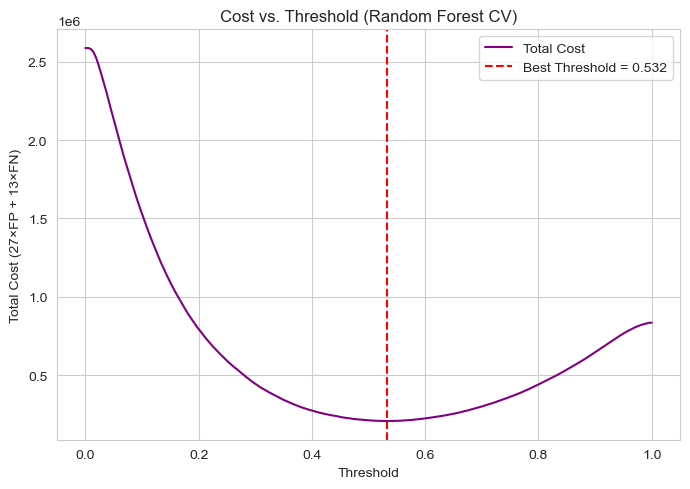

In [78]:
sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))
plt.plot(thresholds, costs, label="Total Cost", color='purple')
plt.axvline(best_threshold, linestyle='--', color='red', label=f"Best Threshold = {best_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Total Cost (27×FP + 13×FN)")
plt.title("Cost vs. Threshold (Random Forest CV)")
plt.legend()
plt.tight_layout()
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94     95803
           1       0.94      0.86      0.90     64197

    accuracy                           0.92    160000
   macro avg       0.93      0.91      0.92    160000
weighted avg       0.92      0.92      0.92    160000

Confusion Matrix:
 [[92603  3200]
 [ 9272 54925]]
AUC: 0.9110838490671516


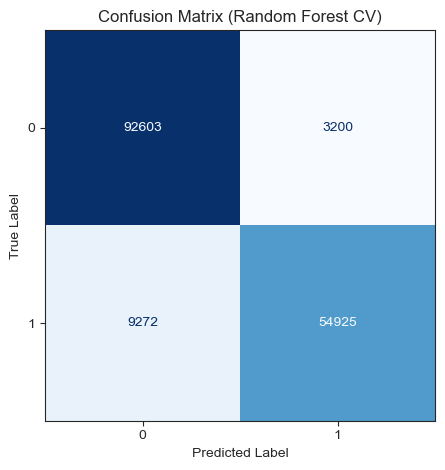

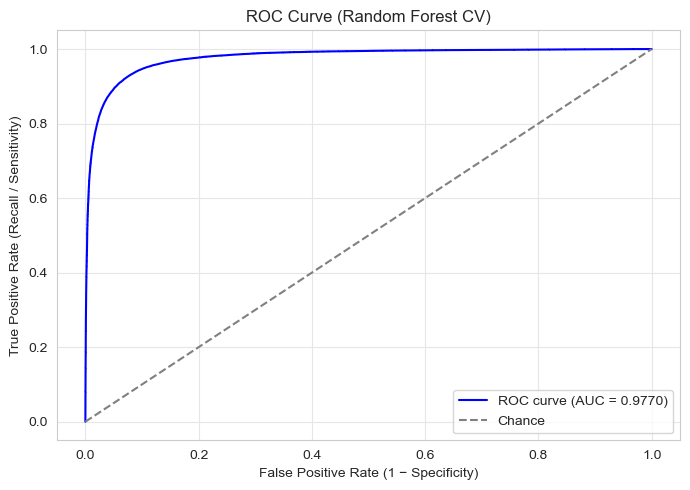

In [79]:
# Final prediction using best threshold
y_thresh_opt = (rf_oof_probs >= best_threshold).astype(int)

# Evaluate
print("Classification Report:\n", classification_report(y, y_thresh_opt))
print("Confusion Matrix:\n", confusion_matrix(y, y_thresh_opt))
print("AUC:", roc_auc_score(y, y_thresh_opt))

# Very simple way to make a confusion matrix plot
# Class labels for ticks (e.g., 0 = Not Bankrupcy, 1 = Bankrupcy)
#class_order = ['Not Bankruptcy', 'Bankruptcy']

# Set Seaborn style
sns.set_style('ticks')

# Create and customize the plot
disp = ConfusionMatrixDisplay.from_predictions(y, y_thresh_opt, cmap='Blues', colorbar=False)

# Now set tick labels on the returned axis
#disp.ax_.set_xticklabels(class_order)
#disp.ax_.set_yticklabels(class_order)
disp.ax_.set_xlabel("Predicted Label")
disp.ax_.set_ylabel("True Label")
disp.ax_.set_title("Confusion Matrix (Random Forest CV)")

plt.tight_layout()
plt.show()

# # ROC Curve
# fpr, tpr, _ = roc_curve(y, oof_probs)
# RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
# plt.title("ROC Curve (Random Forest CV)")
# plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y, rf_oof_probs)
roc_auc = auc(fpr, tpr)

# Set a cleaner seaborn style with lighter grid
sns.set_style("whitegrid", {'axes.grid': True, 'grid.color': '.9'})

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel("False Positive Rate (1 − Specificity)")
plt.ylabel("True Positive Rate (Recall / Sensitivity)")
plt.title("ROC Curve (Random Forest CV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## XGBoost

### Data Setup

In [80]:
# One Hot Encode x24_region
X_encoded = pd.get_dummies(X, columns=['x24_region'], drop_first=True)
X_encoded = X_encoded.astype('float32')

# Convert data into XGBoost's DMatrix
all_dm = xgb.DMatrix(X_encoded,label=y)

Hyperparameter Tuning Notes:

tier1: 

- 'max_depth'
- 'subsample'
- 'colsample_bytree'
- 'colsample_bylevel'
- 'colsample_bynode'
- 'lambda'

tier2:

- 'eta'
- 'gamma'

other params:

- 'eval_metric':'auc'  # reported in paper
- 'objective':'binary:logistic'  # binary target class
- num_boost_round = 1000  # set high but aim for stopping between 200 and 500 (can change learning rate)
- early_stopping_rounds = 10  # choose 5 or 10


### Hyperparameter Tuning

In [81]:
# Set base XGBoost parameters (fixed)
params = {'eval_metric':'auc',
          'objective':'binary:logistic'}


def XGBRandomSearch(params, data, n_iter=50, seed=SEED):
    """
    Performs a random hyperparameter search for XGBoost using cross-validation.

    Parameters:
    - params: dict, base parameters for XGBoost (e.g. objective, eval_metric)
    - data: xgb.DMatrix, dataset with features and labels
    - n_iter: int, number of random parameter combinations to try
    - seed: int or None, random seed for reproducibility (affects both sampling and folds)

    Returns:
    - best_result: DataFrame of cv results from best parameter set
    - best_score: highest AUC score observed during search
    - best_params: parameter set that produced best AUC
    - best_num_rounds: number of boosting rounds used by best model
    """
    if seed is not None:
        np.random.seed(seed)  # Fix random sampling of hyperparameters
    
    best_score = 0
    best_params = 'error'   # Will hold the best parameter combination found
    best_result = None
    best_num_rounds = None  # Track number of boosting rounds for best model
    
    # Generate random values for each hyperparameter for all iterations
    max_d = np.random.choice([15, 20, 25, 30, 35],n_iter) # focused max_depth from my random forest model 25-30 worked well
    subs = 0.5+np.random.random(n_iter)/2                   # Random values between 0.5 and 1 for row and column subsamples
    colsample_bytree = 0.5+np.random.random(n_iter)/2       # Random values 0-1, divide by 2, add 0.5
    colsample_bylevel = 0.5+np.random.random(n_iter)/2 
    colsample_bynode = 0.5+np.random.random(n_iter)/2
    reg_lambda = np.random.choice([1e-2,1e-1,1,1e1,1e2],n_iter)  # Regularization strengths
    etas = np.random.choice([0.3, 0.2, 0.1, 0.05], size=n_iter)  # Was stopping after 185 rounds, so trying smaller learning rates

    # Iterate through each random combination
    for i in range(n_iter):
        # Make a fresh copy of the base params and update with randomly selected values
        iter_params = copy.deepcopy(params)
        iter_params['max_depth'] = max_d[i]
        iter_params['subsample'] = subs[i]
        iter_params['colsample_bytree'] = colsample_bytree[i]
        iter_params['colsample_bylevel'] = colsample_bylevel[i]
        iter_params['colsample_bynode'] = colsample_bynode[i]
        iter_params['reg_lambda'] = reg_lambda[i]
        iter_params['eta'] = etas[i]
        
        # Perform 5-fold stratified cross-validation
        f=xgb.cv(iter_params, dtrain=data, 
                 nfold=5, stratified=True, 
                 metrics=['auc','error'],                    # error is misclassification rate
                 num_boost_round=1000, early_stopping_rounds=10,
                 seed=SEED   # Fix CV folds for reproducibility
                )
        
        # Warn if the boosting round limit is hit (may need to increase num_boost_round)
        if f.shape[0] == 1000:
            print("Warning hit limit")
        
        # Print current parameters and AUC
        print(iter_params,f['test-auc-mean'].max(), f['test-error-mean'].max())

        # Update best score and parameters if this round is better
        if f['test-auc-mean'].max() > best_score:
            best_score = f['test-auc-mean'].max()
            best_params = copy.deepcopy(iter_params)
            best_result = f.copy()   # Save the *current* result that achieved best score
            best_num_rounds = f.shape[0]  # Save best round count

    return best_result, best_score, best_params, best_num_rounds


In [82]:
# Time hypertuning
start = time.perf_counter()

# Run random search and save results
best_result, best_score, best_params, best_num_rounds = XGBRandomSearch(params, all_dm, n_iter=50, seed=SEED)

end = time.perf_counter()
print(f"Elapsed time: {((end - start)/60):.3f} minutes")

{'eval_metric': 'auc', 'objective': 'binary:logistic', 'max_depth': 25, 'subsample': 0.5557631839522446, 'colsample_bytree': 0.9428446738692116, 'colsample_bylevel': 0.6126751503804551, 'colsample_bynode': 0.6110744072622898, 'reg_lambda': 1.0, 'eta': 0.1} 0.9824325417976884 0.40123125000000004
{'eval_metric': 'auc', 'objective': 'binary:logistic', 'max_depth': 15, 'subsample': 0.9183242631129251, 'colsample_bytree': 0.815968487944551, 'colsample_bylevel': 0.5223124539795417, 'colsample_bynode': 0.5969821567040432, 'reg_lambda': 1.0, 'eta': 0.1} 0.9840780520547048 0.40123125000000004
{'eval_metric': 'auc', 'objective': 'binary:logistic', 'max_depth': 25, 'subsample': 0.6359777647144956, 'colsample_bytree': 0.5557233610919063, 'colsample_bylevel': 0.8484762909675893, 'colsample_bynode': 0.8489528383272273, 'reg_lambda': 0.1, 'eta': 0.3} 0.9783956116373037 0.27175000000000005
{'eval_metric': 'auc', 'objective': 'binary:logistic', 'max_depth': 15, 'subsample': 0.8090566050091589, 'colsamp

In [83]:
print(best_result, best_score, best_params, best_num_rounds)

     train-auc-mean  train-auc-std  train-error-mean  train-error-std  \
0          0.986553       0.000158          0.401231         0.000004   
1          0.998475       0.000095          0.153070         0.006614   
2          0.999670       0.000021          0.058508         0.002470   
3          0.999886       0.000013          0.022502         0.000564   
4          0.999950       0.000007          0.010739         0.000366   
..              ...            ...               ...              ...   
172        1.000000       0.000000          0.000000         0.000000   
173        1.000000       0.000000          0.000000         0.000000   
174        1.000000       0.000000          0.000000         0.000000   
175        1.000000       0.000000          0.000000         0.000000   
176        1.000000       0.000000          0.000000         0.000000   

     test-auc-mean  test-auc-std  test-error-mean  test-error-std  
0         0.864474      0.001936         0.401231      

### Fit the Final XGB Model (CV)

In [84]:
# best_params and best_num_rounds already selected
# Prepare arrays to collect predictions
oof_preds = np.zeros_like(y, dtype=float)   # Stores predicted probabilities for each fold
oof_labels = np.zeros_like(y, dtype=int)    # Stores final predicted class (0/1) for each fold
rounds_per_fold = []

# Set up cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Time CV predictions with final model
start = time.perf_counter()

for train_idx, valid_idx in kf.split(X_encoded, y):                  # Loops through the 5 train-validation splits 
    X_train, X_valid = X_encoded.iloc[train_idx], X_encoded.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)

    model = xgb.train(
        params=best_params,
        dtrain=dtrain,
        evals=[(dvalid, "eval")],            # required for early stopping
        num_boost_round=1000,
        early_stopping_rounds=10
    )

    preds = model.predict(dvalid)                     # Probabilities [0,1]
    oof_preds[valid_idx] = preds                      # Save probabilities
    oof_labels[valid_idx] = (preds > 0.5).astype(int) # Convert to 0/1 label and store
    rounds_per_fold.append(model.best_iteration + 1)

end = time.perf_counter()
print(f"Elapsed time for CV XGB predictions:: {((end - start)/60):.3f} minutes")

# Rename for combined plotting with NN later
probs_xgb = oof_preds
labels_xgb = oof_labels

[0]	eval-auc:0.86144
[1]	eval-auc:0.90323
[2]	eval-auc:0.93451
[3]	eval-auc:0.94790
[4]	eval-auc:0.95656
[5]	eval-auc:0.96198
[6]	eval-auc:0.96601
[7]	eval-auc:0.96831
[8]	eval-auc:0.96997
[9]	eval-auc:0.97175
[10]	eval-auc:0.97243
[11]	eval-auc:0.97331
[12]	eval-auc:0.97449
[13]	eval-auc:0.97505
[14]	eval-auc:0.97576
[15]	eval-auc:0.97598
[16]	eval-auc:0.97606
[17]	eval-auc:0.97634
[18]	eval-auc:0.97674
[19]	eval-auc:0.97741
[20]	eval-auc:0.97758
[21]	eval-auc:0.97791
[22]	eval-auc:0.97834
[23]	eval-auc:0.97852
[24]	eval-auc:0.97860
[25]	eval-auc:0.97888
[26]	eval-auc:0.97924
[27]	eval-auc:0.97930
[28]	eval-auc:0.97971
[29]	eval-auc:0.97989
[30]	eval-auc:0.98005
[31]	eval-auc:0.98014
[32]	eval-auc:0.98021
[33]	eval-auc:0.98038
[34]	eval-auc:0.98053
[35]	eval-auc:0.98078
[36]	eval-auc:0.98099
[37]	eval-auc:0.98105
[38]	eval-auc:0.98106
[39]	eval-auc:0.98114
[40]	eval-auc:0.98127
[41]	eval-auc:0.98149
[42]	eval-auc:0.98168
[43]	eval-auc:0.98169
[44]	eval-auc:0.98176
[45]	eval-auc:0.9818

### Tune Threshold to Minimize Total Cost

In [85]:
# Evaluate costs over many thresholds
thresholds = np.linspace(0, 1, 1001)
costs = []

for thresh in thresholds:
    y_pred_thresh = (probs_xgb >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred_thresh).ravel()
    cost = 27 * fp + 13 * fn
    costs.append(cost)

# Best threshold and corresponding cost
min_cost_idx = np.argmin(costs)
best_thresh_xgb = thresholds[min_cost_idx]
min_cost = costs[min_cost_idx]

print(f"\nBest Threshold to Minimize Cost: {best_thresh_xgb:.4f}")
print(f"Minimum Total Cost: {min_cost}")


Best Threshold to Minimize Cost: 0.6630
Minimum Total Cost: 155935


### Evaluate Performance at Best Threshold

In [86]:
# Final prediction using best threshold
y_pred_xgb = (probs_xgb >= best_thresh_xgb).astype(int)
y_true = y

print("\nClassification Report (Threshold Optimized):")
print(classification_report(y_true, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_xgb))


Classification Report (Threshold Optimized):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     95803
           1       0.96      0.90      0.93     64197

    accuracy                           0.94    160000
   macro avg       0.95      0.94      0.94    160000
weighted avg       0.94      0.94      0.94    160000

Confusion Matrix:
[[93164  2639]
 [ 6514 57683]]


### Plot Cost vs Threshold

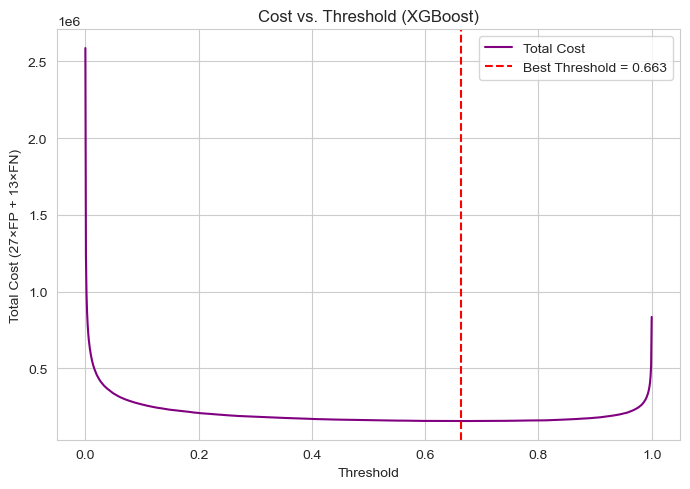

In [87]:
sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))
plt.plot(thresholds, costs, label="Total Cost", color='purple')
plt.axvline(best_thresh_xgb, linestyle='--', color='red', label=f"Best Threshold = {best_thresh_xgb:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Total Cost (27×FP + 13×FN)")
plt.title("Cost vs. Threshold (XGBoost)")
plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'FPs and FNs vs. Threshold (XGBoost)')

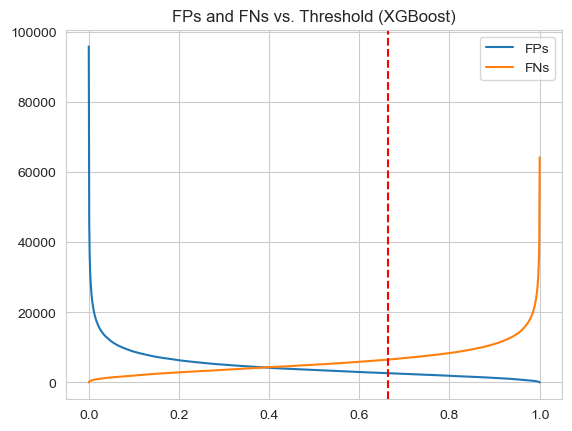

In [88]:
FPs, FNs = [], []

for t in thresholds:
    preds = (probs_xgb >= t).astype(int)
    cm = confusion_matrix(y_true, preds)
    FPs.append(cm[0,1])
    FNs.append(cm[1,0])

plt.plot(thresholds, FPs, label="FPs")
plt.plot(thresholds, FNs, label="FNs")
plt.axvline(best_thresh_xgb, linestyle='--', color='red')
plt.legend()
plt.title("FPs and FNs vs. Threshold (XGBoost)")


Best XGB Params:
 {'eval_metric': 'auc', 'objective': 'binary:logistic', 'max_depth': 25, 'subsample': 0.9911120103192255, 'colsample_bytree': 0.7472811041432285, 'colsample_bylevel': 0.859493112916273, 'colsample_bynode': 0.8393039688316735, 'reg_lambda': 0.01, 'eta': 0.1}
Boosting rounds per fold: [212, 276, 271, 238, 227]
Classification Report:
               precision    recall  f1-score   support

         0.0     0.9346    0.9725    0.9532     95803
         1.0     0.9563    0.8985    0.9265     64197

    accuracy                         0.9428    160000
   macro avg     0.9455    0.9355    0.9398    160000
weighted avg     0.9433    0.9428    0.9425    160000

Confusion Matrix:
 [[93164  2639]
 [ 6514 57683]]
AUC: 0.984911626146496


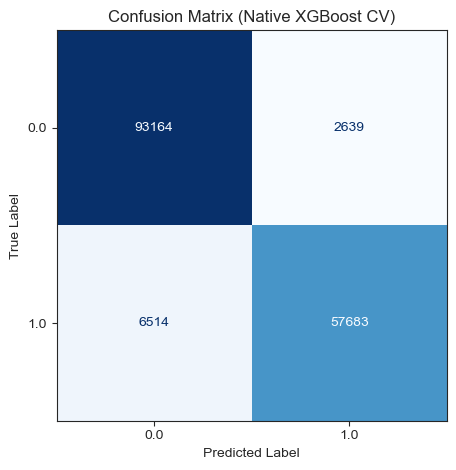

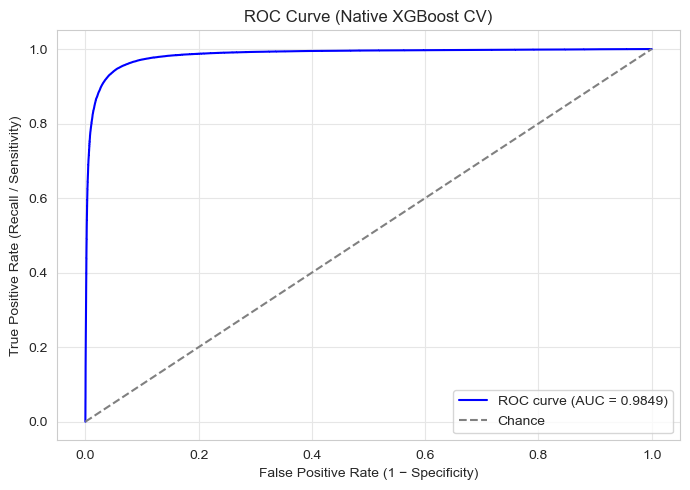

In [205]:
# Now evaluate
print("Best XGB Params:\n", best_params)
print("Boosting rounds per fold:", rounds_per_fold)
print("Classification Report:\n", classification_report(y_true, y_pred_xgb, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_xgb))
print("AUC:", roc_auc_score(y_true, probs_xgb))

# # ROC curve
# fpr, tpr, _ = roc_curve(y, oof_preds)
# RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
# plt.title("ROC Curve (Native XGBoost CV)")
# plt.show()

# Very simple way to make a confusion matrix plot
# Class labels for ticks (e.g., 0 = Not Bankrupcy, 1 = Bankrupcy)
# class_order = ['Not Bankruptcy', 'Bankruptcy']

# Set Seaborn style
sns.set_style('ticks')

# Create and customize the plot
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred_xgb, cmap='Blues', colorbar=False)

# Now set tick labels on the returned axis
# disp.ax_.set_xticklabels(class_order)
# disp.ax_.set_yticklabels(class_order)
disp.ax_.set_xlabel("Predicted Label")
disp.ax_.set_ylabel("True Label")
disp.ax_.set_title("Confusion Matrix (Native XGBoost CV)")

plt.tight_layout()
plt.show()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, probs_xgb)
roc_auc = auc(fpr, tpr)

# Set a cleaner seaborn style with lighter grid
sns.set_style("whitegrid", {'axes.grid': True, 'grid.color': '.9'})

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel("False Positive Rate (1 − Specificity)")
plt.ylabel("True Positive Rate (Recall / Sensitivity)")
plt.title("ROC Curve (Native XGBoost CV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# CV_boosting_rounds:

## Neural Net

### Set up GPU

In [90]:
colab = False

In [91]:
# Verify PyTorch with MPS Support is available
if torch.backends.mps.is_available():
    print("MPS backend is available.")
    mps_device = torch.device("mps")
else:
    print("MPS backend not available.")

MPS backend is available.


In [92]:
# To use M4 GPU, send tensors or models to the mps device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

### Data setup

#### Dataset definition

In [93]:
# Get data into the model: Data wrapper class
'''
This class defines how the input data (X) and target labels (y) are wrapped into a PyTorch-compatible format and returned one sample at a time. It enables the use of DataLoader for batching and shuffling.
'''
class AnonymousDataset(Dataset):
    '''
    A custom dataset wrapper class that allows you to define how your data is:
      - stored
      - indexed (__getitem__)
      - returned in batches by a DataLoader
    It wraps the raw data into tensors for PyTorch to understand.
    '''
    def __init__(self, X_dataFrame, y_dataFrame, transform=None, target_transform=None):
        self.X = X_dataFrame
        # self.y = y_dataFrame.squeeze().astype("float32") # Remove extra dimensions if needed
        self.y = y_dataFrame.squeeze().to_numpy().astype("float32")
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return self.X.shape[0] # Returns the number of samples

    def __getitem__(self, idx):
        # Convert one row of X and its corresponding label y to tensors
        inputs = torch.tensor(self.X[idx]).float()
        target = torch.tensor(self.y[idx]).float()
        if self.transform:
            inputs = self.transform(inputs)
        if self.target_transform:
            target = self.target_transform(target)
        return inputs, target

#### Preprocessing Setup

In [94]:
imputed_data.columns

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x7', 'x8', 'x9', 'x10', 'x11',
       'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21',
       'x22', 'x23', 'x24_region', 'x25', 'x26', 'x27', 'x28', 'x29_month_cat',
       'x29_month_num', 'x30_weekday_cat', 'x30_weekday_num', 'x31',
       'x32_percent', 'x33', 'x34', 'x35', 'x36', 'x37_dollar_amt', 'x39',
       'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49',
       'y'],
      dtype='object')

In [95]:
# # Optionally drop x29_month_num and replace with sin/cos:
# X['month_sin'] = np.sin(2 * np.pi * X['x29_month_num'] / 12)
# X['month_cos'] = np.cos(2 * np.pi * X['x29_month_num'] / 12)
# num_cols += ['month_sin', 'month_cos']
# num_cols.remove('x29_month_num')

In [96]:
# Define preprocessing pipeline (fit inside CV loop)
cat_cols = ['x24_region', 'x30_weekday_cat']
drop_cols = ['x29_month_cat', 'x30_weekday_num', 'y']

X_nn = imputed_data.drop(columns=drop_cols)
y_nn = imputed_data['y'] 

num_cols = [col for col in X_nn.columns if col not in cat_cols]

In [97]:
# Sanity check for missing values
assert not X_nn.isna().any().any(), "Missing values found in predictors"
assert not y_nn.isna().any(), "Missing values found in target"

### Define checkpoints

In [98]:
# To clear checkpoints so models run independently
def clear_checkpoints(model_name):
    """Clear all checkpoints for a specific model to ensure fresh training"""
    pattern = f"logs/{model_name}*/**/*.ckpt"
    ckpts = glob.glob(pattern, recursive=True)
    for f in ckpts:
        print(f"Deleting: {f}")
        os.remove(f)
    print(f"Cleared {len(ckpts)} checkpoints for {model_name}")

In [99]:
# For each model's logger
if colab:
    logs_dir = os.path.join(base_path, "logs")  # Saves to Google Drive
else:
    logs_dir = "logs"  # Saves locally in current directory

### Network Definition

In [100]:
class MyFirstNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        '''
        The init and forward class functions are part of every Network.
        '''
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1000),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(1000, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        outputs = self.model(x)
        return outputs

In [101]:
# Lightning Module
class FirstModel(pl.LightningModule):
    """
    A PyTorch Lightning module for binary classification using a dense neural network.

    This module wraps:
    - A fully connected feedforward network (`MyDenseNetwork`) with sigmoid output
    - Binary cross-entropy loss (`nn.BCELoss`) for training
    - Accuracy calculation using a 0.5 threshold on predicted probabilities
    - Logging of training and validation loss and accuracy to the configured logger

    Optimization details:
    - Uses the Adam optimizer with a fixed learning rate
    - Gradients are automatically computed (`loss.backward()`), optionally clipped,
      used to update weights (`optimizer.step()`), and zeroed out after each step
      (`optimizer.zero_grad()`), all handled by Lightning

    The model is trained in mini-batches, with one weight update per batch.
    The loss returned from `training_step` is used by Lightning to manage
    backpropagation and optimization.

    This module integrates seamlessly with callbacks like early stopping.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.model = MyFirstNetwork(input_dim)
        self.loss = nn.BCELoss()

        # Metrics
        self.train_auc = BinaryAUROC()
        self.val_auc = BinaryAUROC()
        self.train_precision = BinaryPrecision()
        self.val_precision = BinaryPrecision()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        loss = self.loss(y_hat, y)

        # Metrics
        self.train_auc.update(y_hat, y.int())
        self.train_precision.update(y_hat, y.int())

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        loss = self.loss(y_hat, y)

        self.val_auc.update(y_hat, y.int())
        self.val_precision.update(y_hat, y.int())

        self.log("val_loss", loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.log("train_auc", self.train_auc.compute(), prog_bar=True)
        self.log("train_precision", self.train_precision.compute(), prog_bar=True)
        self.train_auc.reset()
        self.train_precision.reset()

    def on_validation_epoch_end(self):
        self.log("val_auc", self.val_auc.compute(), prog_bar=True)
        self.log("val_precision", self.val_precision.compute(), prog_bar=True)
        self.val_auc.reset()
        self.val_precision.reset()

    # Don't need this because doing manual CV not using .predict, but doesn't hurt
    def predict_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        return y_hat.cpu(), y.cpu()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
        return optimizer


### Early Stopping

In [102]:
# Setup early stopping
'''
Monitors the validation auc during training and stops early if the model stops improving.
- monitor="val_accuracy": The metric to track.
- mode="max": Trying to maximize auc.
- patience=5: Training stops if there's no improvement in validation accuracy for 5 consecutive epochs.
- Since min_delta is not specified, it defaults to 0, meaning any improvement resets the patience counter.
'''

early_stop_callback = EarlyStopping(
    monitor="val_auc",  # Metric to monitor (must be logged in `validation_step`)
    mode="max",              # "min" for loss, "max" for accuracy
    patience=5,              # Number of epochs with no improvement before stopping
    verbose=True
)

### Checkpoint callback

### Training and Cross-Validation Loop

In [ ]:
# Clear all old checkpoints once at the start
def clear_all_checkpoints():
    ckpt_root = "checkpoints"
    if os.path.exists(ckpt_root):
        print("Removing old checkpoints...")
        shutil.rmtree(ckpt_root)
    os.makedirs(ckpt_root, exist_ok=True)

clear_all_checkpoints()

# Setup K-Fold CV
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Initialize storage for OOF predictions and tracking
oof_probs = np.zeros(len(y_nn), dtype=np.float32)
oof_true = np.zeros(len(y_nn), dtype=np.float32)
fold_aucs = []
best_paths = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_nn, y_nn)):
    print(f"\n--- Fold {fold+1} ---")

    # Make fold_ckpt_dir unique per config
    fold_ckpt_dir = f"checkpoints/config{i+1}_fold{fold+1}"
    if os.path.exists(fold_ckpt_dir):
        shutil.rmtree(fold_ckpt_dir)
    os.makedirs(fold_ckpt_dir, exist_ok=True)

    checkpoint_callback = ModelCheckpoint(
        monitor="val_auc",
        mode="max",
        save_top_k=1,
        dirpath=fold_ckpt_dir,
        filename="best",
        save_weights_only=False
    )
    early_stop_callback = EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        verbose=True
    )

    # Split data
    X_train_raw, X_val_raw = X_nn.iloc[train_idx], X_nn.iloc[val_idx]
    y_train, y_val = y_nn.iloc[train_idx], y_nn.iloc[val_idx]

    # Fit preprocessing pipeline per fold
    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            # ('impute', SimpleImputer(strategy='mean')),
            ('scale', StandardScaler())
        ]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    X_train = preprocessor.fit_transform(X_train_raw).astype("float32")
    X_val = preprocessor.transform(X_val_raw).astype("float32")
    input_dim = X_train.shape[1]
    print(f"Input dim for Fold {fold+1}: {input_dim}")

    # Prepare datasets and loaders
    train_ds = AnonymousDataset(X_train, y_train)
    val_ds = AnonymousDataset(X_val, y_val)

    if colab:
        train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True, num_workers=11)
        val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False, num_workers=11)
    else:
        train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False, num_workers=0)

    # Initialize model and trainer
    model = FirstModel(input_dim=input_dim)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_log = CSVLogger(save_dir=logs_dir, name=f"first_model_fold{fold+1}", version=timestamp)

    trainer = pl.Trainer(
        max_epochs=1000,
        logger=csv_log,
        callbacks=[early_stop_callback, checkpoint_callback],
        accelerator="auto",
        log_every_n_steps=50,
        enable_progress_bar=False
    )

    # Train
    start = time.time()
    trainer.fit(model, train_loader, val_loader, ckpt_path=None)
    end = time.time()
    print(f"Training completed in {(end - start)/60:.2f} minutes. Stopped at epoch {trainer.current_epoch + 1}")

    # Predict
    preds, truths = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            out = model(xb).squeeze()
            preds.append(out.cpu().numpy())
            truths.append(yb.cpu().numpy())

    oof_probs[val_idx] = np.concatenate(preds)
    oof_true[val_idx] = np.concatenate(truths)

    # Evaluate
    fold_auc = roc_auc_score(oof_true[val_idx], oof_probs[val_idx])
    fold_aucs.append(fold_auc)
    best_paths.append(checkpoint_callback.best_model_path)
    print(f"Fold {fold+1} AUC: {fold_auc:.4f}")
    print(f"Checkpoint saved to: {checkpoint_callback.best_model_path}")

# After all folds
best_fold = np.argmax(fold_aucs)
print(f"\nBest overall fold: {best_fold+1} with AUC = {fold_aucs[best_fold]:.4f}")
print(f"Best model checkpoint: {best_paths[best_fold]}")

# Load best model from checkpoint
best_model = FirstModel.load_from_checkpoint(
    checkpoint_path=best_paths[best_fold],
    input_dim=X_train.shape[1]
)

# Optionally inspect saved checkpoints
print("\nCheckpoints after run:")
for root, dirs, files in os.walk("checkpoints"):
    for name in files:
        print(os.path.join(root, name))



--- Fold 1 ---


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type            | Params | Mode 
------------------------------------------------------------
0 | model           | MyFirstNetwork  | 3.1 M  | train
1 | loss            | BCELoss         | 0      | train
2 | train_auc       | BinaryAUROC     | 0      | train
3 | val_auc         | BinaryAUROC     | 0      | train
4 | train_precision | BinaryPrecision | 0      | train
5 | val_precision   | BinaryPrecision | 0      | train
------------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.236    Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Input dim for Fold 1: 54


/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (125) is smaller than the logging interval Trainer(log_every_n_steps=500). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/torchmetrics/utilit

Training completed in 2.14 minutes. Stopped at epoch 60


...

Training completed in 2.59 minutes. Stopped at epoch 73


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Fold 4 AUC: 0.9919
Checkpoint saved to: /Users/kdhenderson/Desktop/currentDesktop/SMU/ds7333_QTW/caseStudy07/checkpoints/config2_fold4/best.ckpt

--- Fold 5 ---
Input dim for Fold 5: 54



  | Name            | Type            | Params | Mode 
------------------------------------------------------------
0 | model           | MyFirstNetwork  | 3.1 M  | train
1 | loss            | BCELoss         | 0      | train
2 | train_auc       | BinaryAUROC     | 0      | train
3 | val_auc         | BinaryAUROC     | 0      | train
4 | train_precision | BinaryPrecision | 0      | train
5 | val_precision   | BinaryPrecision | 0      | train
------------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.236    Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode
/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to impr

Training completed in 2.76 minutes. Stopped at epoch 76
Fold 5 AUC: 0.9917
Checkpoint saved to: /Users/kdhenderson/Desktop/currentDesktop/SMU/ds7333_QTW/caseStudy07/checkpoints/config2_fold5/best.ckpt

Best overall fold: 1 with AUC = 0.9923
Best model checkpoint: /Users/kdhenderson/Desktop/currentDesktop/SMU/ds7333_QTW/caseStudy07/checkpoints/config2_fold1/best.ckpt

Checkpoints after run:
checkpoints/config2_fold1/best.ckpt
checkpoints/config2_fold2/best.ckpt
checkpoints/config2_fold5/best.ckpt
checkpoints/config2_fold4/best.ckpt
checkpoints/config2_fold3/best.ckpt


### Revised Training Loop for Hyperparameter Tuning

In [105]:
class MyTuningNetwork(nn.Module):
    def __init__(self, input_dim, dropout=0.2, activation='SiLU'):
        super().__init__()

        # Map string to activation function
        act_fn_map = {
            'SiLU': nn.SiLU(),
            'GELU': nn.GELU()
        }

        act_fn = act_fn_map.get(activation, nn.SiLU())  # default to SiLU

        self.model = nn.Sequential(
            nn.Linear(input_dim, 1000),
            act_fn,
            nn.Dropout(dropout),
            nn.Linear(1000, 1000),
            act_fn,
            nn.Dropout(dropout),
            nn.Linear(1000, 1000),
            act_fn,
            nn.Dropout(dropout),
            nn.Linear(1000, 1000),
            act_fn,
            nn.Dropout(dropout),
            nn.Linear(1000, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [106]:
# Lightning Module
class TuningModel(pl.LightningModule):
    def __init__(self, input_dim, dropout=0.2, activation='SiLU', lr=1e-4):
        super().__init__()
        self.model = MyTuningNetwork(input_dim, dropout=dropout, activation=activation)
        self.loss = nn.BCELoss()
        self.lr = lr 

        # Metrics
        self.train_auc = BinaryAUROC()
        self.val_auc = BinaryAUROC()
        self.train_precision = BinaryPrecision()
        self.val_precision = BinaryPrecision()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        loss = self.loss(y_hat, y)

        # Metrics
        self.train_auc.update(y_hat, y.int())
        self.train_precision.update(y_hat, y.int())

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        loss = self.loss(y_hat, y)

        self.val_auc.update(y_hat, y.int())
        self.val_precision.update(y_hat, y.int())

        self.log("val_loss", loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.log("train_auc", self.train_auc.compute(), prog_bar=True)
        self.log("train_precision", self.train_precision.compute(), prog_bar=True)
        self.train_auc.reset()
        self.train_precision.reset()

    def on_validation_epoch_end(self):
        self.log("val_auc", self.val_auc.compute(), prog_bar=True)
        self.log("val_precision", self.val_precision.compute(), prog_bar=True)
        self.val_auc.reset()
        self.val_precision.reset()

    # Don't need this because doing manual CV not using .predict, but doesn't hurt
    def predict_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x).squeeze()
        return y_hat.cpu(), y.cpu()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer



In [107]:
param_grid = {
    'lr': [5e-4, 1e-4, 5e-5], # had ->'lr': [5e-4, 1e-4, 5e-5, 1e-5],
    'dropout': [0.2, 0.5],
    'activation': ['SiLU', 'GELU'],
    'batch_size': [1024, 2056]
}

search_space = list(product(*param_grid.values()))
param_names = list(param_grid.keys())

In [109]:
print(f"Run seed: {SEED}")
print(f"Number of configs: {len(search_space)}")
print(f"Timestamp: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Utility to clear all checkpoints at the beginning of the tuning run
def clear_all_checkpoints():
    ckpt_root = "checkpoints"
    if os.path.exists(ckpt_root):
        print("Removing old checkpoints...")
        shutil.rmtree(ckpt_root)
    os.makedirs(ckpt_root, exist_ok=True)

clear_all_checkpoints()

# Create the directory for storing oof predictions
os.makedirs("oof_preds", exist_ok=True)

# Setup cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

summary_rows = []
best_auc = -np.inf
best_config = None
best_model_path = None

completed_configs = set()
summary_path = "tuning_summary.csv"

if os.path.exists(summary_path):
    prev_summary = pd.read_csv(summary_path)
    completed_configs = set(prev_summary["config_id"])
    summary_rows = prev_summary.to_dict(orient="records")  # resume previous state

# === Outer loop: over hyperparameter configurations ===
for i, values in enumerate(search_space):
    config_start = time.time()
    if (i + 1) in completed_configs:
        print(f"Skipping config {i+1} (already completed)")
        continue
    print(f"\n>>> Starting config {i+1} of {len(search_space)}")

    config = dict(zip(param_names, values))
    print(f"Config params: {config}")

    # Clear checkpoints for this config from prior failed runs (if any)
    for fold in range(1, 6):
        fold_ckpt_dir = f"checkpoints/config{i+1}_fold{fold}"
        if os.path.exists(fold_ckpt_dir):
            shutil.rmtree(fold_ckpt_dir)

    # Initialize OOF storage for this config
    oof_probs = np.zeros(len(y_nn), dtype=np.float32)
    oof_true = np.zeros(len(y_nn), dtype=np.float32)
    fold_aucs = []
    train_aucs = []
    auc_gaps = []
    best_paths = []

    # === Inner loop: 5-fold CV ===
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_nn, y_nn)):
        print(f"\n--- Fold {fold+1} ---")
    
        # Unique per-config, per-fold directory
        fold_ckpt_dir = f"checkpoints/config{i+1}_fold{fold+1}"
        os.makedirs(fold_ckpt_dir, exist_ok=True)

        # Instantiate new callbacks per fold to avoid shared state or interference
        checkpoint_callback = ModelCheckpoint(
            monitor="val_auc",
            mode="max",
            save_top_k=1,
            dirpath=fold_ckpt_dir,
            filename="best",
            save_weights_only=False
        )
        early_stop_callback = EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            verbose=True
        )
    
        # Train/val split and preprocessing per fold
        X_train_raw, X_val_raw = X_nn.iloc[train_idx], X_nn.iloc[val_idx]
        y_train, y_val = y_nn.iloc[train_idx], y_nn.iloc[val_idx]
    
        # Fit preprocessing pipeline per fold
        preprocessor = ColumnTransformer([
            ('num', Pipeline([
                # ('impute', SimpleImputer(strategy='mean')),
                ('scale', StandardScaler())
            ]), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ])
    
        X_train = preprocessor.fit_transform(X_train_raw).astype("float32")
        X_val = preprocessor.transform(X_val_raw).astype("float32")
        input_dim = X_train.shape[1]
        print(f"Input dim for Fold {fold+1}: {input_dim}")
    
        # Prepare datasets and loaders
        train_ds = AnonymousDataset(X_train, y_train)
        val_ds = AnonymousDataset(X_val, y_val)

        # DataLoader setup using tuned batch size
        if colab:
            train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True, num_workers=11)
            val_loader = DataLoader(val_ds, batch_size=config['batch_size'], shuffle=False, num_workers=11)
        else:
            train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True, num_workers=0)
            val_loader = DataLoader(val_ds, batch_size=config['batch_size'], shuffle=False, num_workers=0)

        # Initialize tuning model passing hyperparameters to your model
        model = TuningModel(
            input_dim=input_dim,
            dropout=config['dropout'],
            activation=config['activation'],
            lr=config['lr']
        )
        
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        csv_log = CSVLogger(save_dir=logs_dir, name=f"tuning_model_fold{fold+1}", version=timestamp)

        # Instantiate the model
        trainer = pl.Trainer(
            max_epochs=1000,
            logger=csv_log,
            callbacks=[early_stop_callback, checkpoint_callback],
            accelerator="auto",
            log_every_n_steps=50,
            enable_progress_bar=False  # <- Prevents widget output errors
        )
    
        # Train
        start = time.time()
        trainer.fit(model, train_loader, val_loader, ckpt_path=None)
        end = time.time()
        print(f"Training completed in {(end - start)/60:.2f} minutes. Stopped at epoch {trainer.current_epoch + 1}")
    
        # Predict on validation set
        preds, truths = [], []
        model.eval()
        with torch.no_grad():
            for xb, yb in val_loader:
                out = model(xb).squeeze()
                preds.append(out.cpu().numpy())
                truths.append(yb.cpu().numpy())
    
        oof_probs[val_idx] = np.concatenate(preds)
        oof_true[val_idx] = np.concatenate(truths)
    
        # Store metrics and checkpoint path
        fold_auc = roc_auc_score(oof_true[val_idx], oof_probs[val_idx])
        fold_aucs.append(fold_auc)

        best_paths.append(checkpoint_callback.best_model_path)
        print(f"Fold {fold+1} AUC: {fold_auc:.4f}")
        print(f"Checkpoint saved to: {checkpoint_callback.best_model_path}")

        # Optional: track training AUC to detect overfitting
        train_preds, train_truths = [], []
        model.eval()
        with torch.no_grad():
            for xb, yb in train_loader:
                out = model(xb).squeeze()
                train_preds.append(out.cpu().numpy())
                train_truths.append(yb.cpu().numpy())

        train_auc = roc_auc_score(np.concatenate(train_truths), np.concatenate(train_preds))
        train_aucs.append(train_auc)
        print(f"Fold {fold+1} Train AUC: {train_auc:.4f}")

        auc_gap = train_auc - fold_auc
        auc_gaps.append(auc_gap)

    avg_auc = np.mean(fold_aucs)
    print(f"Avg AUC for config {i+1}: {avg_auc:.4f}")

    # Save OOF predictions per config (for threshold tuning, confusion, etc.)
    np.savez_compressed(f"oof_preds/config_{i+1}_oof.npz", probs=oof_probs, true=oof_true)

    # After all 5 folds for this config
    best_fold = np.argmax(fold_aucs)
    print(f"\nBest overall fold: {best_fold+1} with AUC = {fold_aucs[best_fold]:.4f}")
    # Print checkpoints (optional)
    print(f"Best model checkpoint: {best_paths[best_fold]}")

    # Best config tracking
    if avg_auc > best_auc:
        best_auc = avg_auc
        best_config = config
        best_model_path = best_paths[best_fold]

    summary_rows.append({
    "config_id": i + 1,
    "lr": config["lr"],
    "dropout": config["dropout"],
    "activation": config["activation"],
    "batch_size": config["batch_size"],
    "val_auc": avg_auc,
    "train_auc": np.mean(train_aucs),
    "auc_gap": np.mean(auc_gaps)
    })

    # Incremental saving after each config
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv("tuning_summary.csv", index=False)
    print("Saved tuning_summary.csv (after config {})".format(i + 1))

    # Load best model from checkpoint
    best_model = TuningModel.load_from_checkpoint(
        checkpoint_path=best_paths[best_fold],
        input_dim=X_train.shape[1]
    )
    
    # Optionally inspect saved checkpoints
    print("\nCheckpoints after run:")
    for root, dirs, files in os.walk("checkpoints"):
        for name in files:
            print(os.path.join(root, name))

print(f"Config {i+1} runtime: {(time.time() - config_start)/60:.2f} minutes")

print("\n=== Best Config Summary ===")
print(f"Val AUC: {best_auc:.4f}")
print(f"Config: {best_config}")
print(f"Checkpoint: {best_model_path}")

with open("best_config.json", "w") as f:
    json.dump({
        "val_auc": best_auc,
        "config": best_config,
        "checkpoint": best_model_path
    }, f, indent=2)



Run seed: 13
Number of configs: 24
Timestamp: 2025-07-31 00:22:56

>>> Starting config 1 of 24
Config params: {'lr': 0.0005, 'dropout': 0.2, 'activation': 'SiLU', 'batch_size': 1024}

--- Fold 1 ---


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type            | Params | Mode 
------------------------------------------------------------
0 | model           | MyTuningNetwork | 3.1 M  | train
1 | loss            | BCELoss         | 0      | train
2 | train_auc       | BinaryAUROC     | 0      | train
3 | val_auc         | BinaryAUROC     | 0      | train
4 | train_precision | BinaryPrecision | 0      | train
5 | val_precision   | BinaryPrecision | 0      | train
------------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.236    Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode


Input dim for Fold 1: 54


/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)
Metric val_auc improved. New best score: 0.935
Metric val_auc improved by 0.028 >= min_delta = 0.0. New b

Training completed in 0.86 minutes. Stopped at epoch 23
Fold 1 AUC: 0.9913
Checkpoint saved to: /Users/kdhenderson/Desktop/currentDesktop/SMU/ds7333_QTW/caseStudy07/checkpoints/config1_fold1/best.ckpt
Fold 1 Train AUC: 0.9992

--- Fold 2 ---


...

Training completed in 26.70 minutes. Stopped at epoch 262
Fold 4 AUC: 0.9926
Checkpoint saved to: /Users/kdhenderson/Desktop/currentDesktop/SMU/ds7333_QTW/caseStudy07/checkpoints/config24_fold4/best.ckpt
Fold 4 Train AUC: 0.9969

--- Fold 5 ---


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type            | Params | Mode 
------------------------------------------------------------
0 | model           | MyTuningNetwork | 3.1 M  | train
1 | loss            | BCELoss         | 0      | train
2 | train_auc       | BinaryAUROC     | 0      | train
3 | val_auc         | BinaryAUROC     | 0      | train
4 | train_precision | BinaryPrecision | 0      | train
5 | val_precision   | BinaryPrecision | 0      | train
------------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.236    Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode


Input dim for Fold 5: 54


/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/QTW311/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)
Metric val_auc improved. New best score: 0.760
Metric val_auc improved by 0.062 >= min_delta = 0.0. New b

Training completed in 31.90 minutes. Stopped at epoch 229
Fold 5 AUC: 0.9915
Checkpoint saved to: /Users/kdhenderson/Desktop/currentDesktop/SMU/ds7333_QTW/caseStudy07/checkpoints/config24_fold5/best.ckpt
Fold 5 Train AUC: 0.9965
Avg AUC for config 24: 0.9922

Best overall fold: 1 with AUC = 0.9926
Best model checkpoint: /Users/kdhenderson/Desktop/currentDesktop/SMU/ds7333_QTW/caseStudy07/checkpoints/config24_fold1/best.ckpt
Saved tuning_summary.csv (after config 24)

Checkpoints after run:
checkpoints/config22_fold3/best.ckpt
checkpoints/config22_fold4/best.ckpt
checkpoints/config20_fold5/best.ckpt
checkpoints/config16_fold1/best.ckpt
checkpoints/config20_fold2/best.ckpt
checkpoints/config7_fold1/best.ckpt
checkpoints/config22_fold5/best.ckpt
checkpoints/config5_fold1/best.ckpt
checkpoints/config22_fold2/best.ckpt
checkpoints/config14_fold1/best.ckpt
checkpoints/config20_fold3/best.ckpt
checkpoints/config20_fold4/best.ckpt
checkpoints/config24_fold4/best.ckpt
checkpoints/config24_fold3

In [110]:
summary = pd.read_csv("tuning_summary.csv")

# Sort by validation AUC
summary = summary.sort_values("val_auc", ascending=False)
summary

,config_id,lr,dropout,activation,batch_size,val_auc,train_auc,auc_gap
13,14,0.00010,0.5,SiLU,2056,0.992522,0.996193,0.003671
20,21,0.00005,0.5,SiLU,1024,0.992459,0.995859,0.003400
5,6,0.00050,0.5,SiLU,2056,0.992450,0.997268,0.004818
12,13,0.00010,0.5,SiLU,1024,0.992441,0.996040,0.003599
15,16,0.00010,0.5,GELU,2056,0.992365,0.996819,0.004454
21,22,0.00005,0.5,SiLU,2056,0.992357,0.995736,0.003379
4,5,0.00050,0.5,SiLU,1024,0.992343,0.997340,0.004996
22,23,0.00005,0.5,GELU,1024,0.992243,0.996462,0.004219
6,7,0.00050,0.5,GELU,1024,0.992196,0.997898,0.005702
23,24,0.00005,0.5,GELU,2056,0.992185,0.996402,0.004217


In [111]:
# The code block didn't finish so this didn't get created

# with open("best_config.json", "r") as f:
#     best = json.load(f)

# best_config_id = int(best['checkpoint'].split("_")[1].replace("config", ""))
# print("Best config ID:", best_config_id)


In [112]:
df = pd.read_csv("tuning_summary.csv")
best_row = df.loc[df["val_auc"].idxmax()]
best_config_id = best_row["config_id"]
print("Best Config ID:", best_config_id)
print("Best Val AUC:", best_row["val_auc"])


Best Config ID: 14
Best Val AUC: 0.9925222123165311


In [113]:
data = np.load(f"oof_preds/config_{best_config_id}_oof.npz")
probs_nn, y_true = data["probs"], data["true"]

# Evaluate costs over many thresholds
thresholds = np.linspace(0, 1, 1001)
costs = []

for thresh in thresholds:
    y_pred_thresh = (probs_nn >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_thresh).ravel()
    cost = 27 * fp + 13 * fn
    costs.append(cost)

# Best threshold and corresponding cost
min_cost_idx = np.argmin(costs)
best_thresh_nn = thresholds[min_cost_idx]
min_cost = costs[min_cost_idx]

print(f"\nBest Threshold to Minimize Cost: {best_thresh_nn:.4f}")
print(f"Minimum Total Cost: {min_cost}")



Best Threshold to Minimize Cost: 0.6990
Minimum Total Cost: 77917


In [114]:
len(probs_nn)

160000

In [115]:
probs_nn[:10], y_true[:10] # very close to 0 or very close to 1

(array([1.8961466e-03, 3.2620558e-03, 4.4404804e-03, 4.3357238e-03,
        9.8783690e-01, 1.2082683e-03, 8.4749800e-01, 9.8789108e-01,
        2.6468895e-04, 9.9474370e-01], dtype=float32),
 array([0., 0., 0., 0., 1., 0., 1., 1., 0., 1.], dtype=float32))

In [203]:
# Final prediction using best threshold
y_pred_nn = (probs_nn >= best_thresh_nn).astype(int)

print("\nClassification Report (Threshold Optimized):")
print(classification_report(y_true, y_pred_nn))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_nn))


Classification Report (Threshold Optimized):
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     95803
         1.0       0.98      0.95      0.96     64197

    accuracy                           0.97    160000
   macro avg       0.97      0.97      0.97    160000
weighted avg       0.97      0.97      0.97    160000

Confusion Matrix:
[[94508  1295]
 [ 3304 60893]]


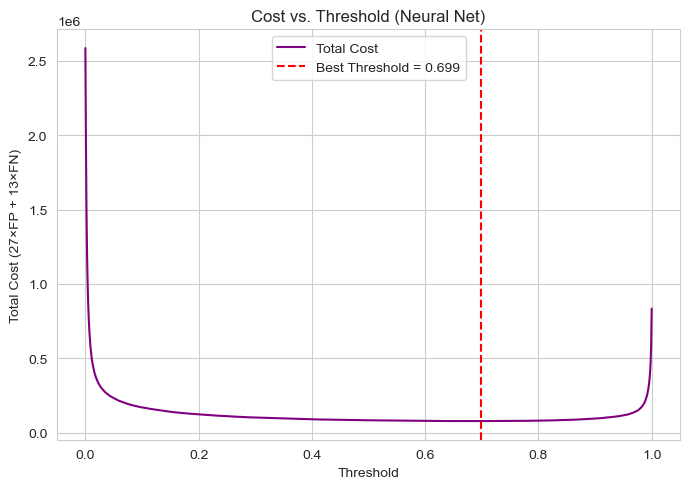

In [117]:
sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))
plt.plot(thresholds, costs, label="Total Cost", color='purple')
plt.axvline(best_thresh_nn, linestyle='--', color='red', label=f"Best Threshold = {best_thresh_nn:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Total Cost (27×FP + 13×FN)")
plt.title("Cost vs. Threshold (Neural Net)")
plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'FPs and FNs vs. Threshold (Neural Net)')

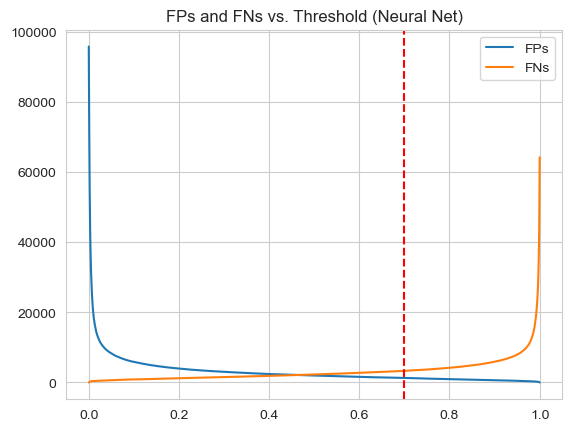

In [118]:
FPs, FNs = [], []

for t in thresholds:
    preds = (probs_nn >= t).astype(int)
    cm = confusion_matrix(y_true, preds)
    FPs.append(cm[0,1])
    FNs.append(cm[1,0])

plt.plot(thresholds, FPs, label="FPs")
plt.plot(thresholds, FNs, label="FNs")
plt.axvline(best_thresh_nn, linestyle='--', color='red')
plt.legend()
plt.title("FPs and FNs vs. Threshold (Neural Net)")

Best Neural Net Config:
 {'lr': 0.0001, 'dropout': 0.5, 'activation': 'SiLU', 'batch_size': 2056}
Best Threshold (NN): 0.6990000000000001

Classification Report (Threshold-Optimized):
              precision    recall  f1-score   support

         0.0     0.9662    0.9865    0.9762     95803
         1.0     0.9792    0.9485    0.9636     64197

    accuracy                         0.9713    160000
   macro avg     0.9727    0.9675    0.9699    160000
weighted avg     0.9714    0.9713    0.9712    160000

Confusion Matrix:
[[94508  1295]
 [ 3304 60893]]
AUC: 0.9924926113645366


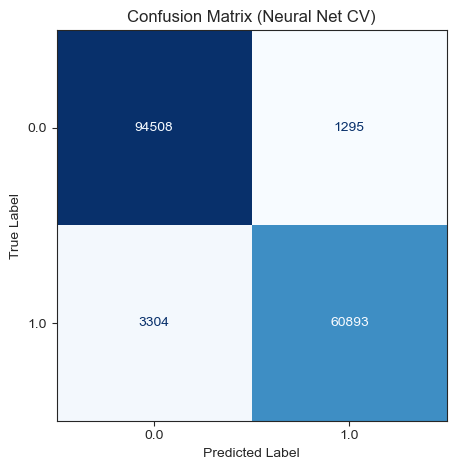

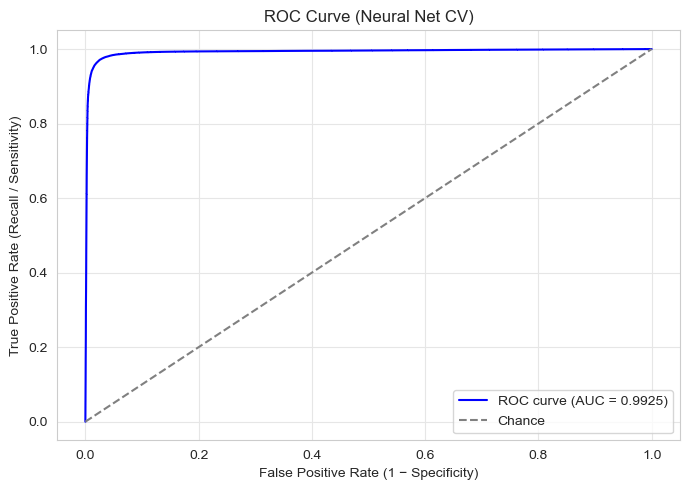

In [204]:
# Apply cost-optimized threshold to get final NN predictions
y_pred_nn = (probs_nn >= best_thresh_nn).astype(int)

# Evaluate classification metrics
print("Best Neural Net Config:\n", best_config)
print("Best Threshold (NN):", best_thresh_nn)
print("\nClassification Report (Threshold-Optimized):")
print(classification_report(y_true, y_pred_nn, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_nn))
print("AUC:", roc_auc_score(y_true, probs_nn))

# Set Seaborn style
sns.set_style('ticks')

# Create and customize the plot
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred_nn, cmap='Blues', colorbar=False)
disp.ax_.set_xlabel("Predicted Label")
disp.ax_.set_ylabel("True Label")
disp.ax_.set_title("Confusion Matrix (Neural Net CV)")
plt.tight_layout()
plt.show()

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, probs_nn)
roc_auc = auc(fpr, tpr)

# Set a cleaner seaborn style with lighter grid
sns.set_style("whitegrid", {'axes.grid': True, 'grid.color': '.9'})

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel("False Positive Rate (1 − Specificity)")
plt.ylabel("True Positive Rate (Recall / Sensitivity)")
plt.title("ROC Curve (Neural Net CV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Combined Plots

In [126]:
def compute_cost_curve(y_true, probs, thresholds):
    costs = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        cost = 27 * fp + 13 * fn
        costs.append(cost)
    return np.array(costs)

def plot_cost_curve_1line(thresholds, costs, best_thresh, model_name, ax):
    ax.plot(thresholds, costs, color='purple')
    ax.axvline(best_thresh, linestyle='--', color='red', label=f"Best Threshold = {best_thresh:.3f}")
    ax.set_title(f"{model_name} Cost vs. Threshold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Total Cost (27×FP + 13×FN)")
    ax.legend()
    ax.grid(True)


In [127]:
def compute_cost_components(y_true, probs, thresholds):
    costs, fps, fns = [], [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        cost = 27 * fp + 13 * fn
        costs.append(cost)
        fps.append(fp)
        fns.append(fn)
    return np.array(costs), np.array(fps), np.array(fns)

def plot_cost_curve(thresholds, costs, fps, fns, best_thresh, model_name, ax):
    ax.plot(thresholds, costs, label="Total Cost", color='purple')
    ax.plot(thresholds, 27 * fps, label="FP Contribution (27×FP)", color='blue', alpha=0.6)
    ax.plot(thresholds, 13 * fns, label="FN Contribution (13×FN)", color='orange', alpha=0.6)
    ax.axvline(best_thresh, linestyle='--', color='red', label=f"Best Threshold = {best_thresh:.3f}")
    ax.set_title(f"{model_name} Cost vs. Threshold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Cost Components")
    ax.legend()
    ax.grid(True)

In [129]:
def plot_pr_curve(y_true, probs, model_name, ax):
    precision, recall, _ = precision_recall_curve(y_true, probs)
    ap = average_precision_score(y_true, probs)
    ax.plot(recall, precision, label=f"AP = {ap:.3f}")
    ax.set_title(f"{model_name} Precision-Recall Curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.grid(True)

In [130]:
# Define thresholds and compute cost curves
thresholds = np.linspace(0, 1, 1001)

costs_xgb = compute_cost_curve(y_true, probs_xgb, thresholds)
costs_nn = compute_cost_curve(y_true, probs_nn, thresholds)

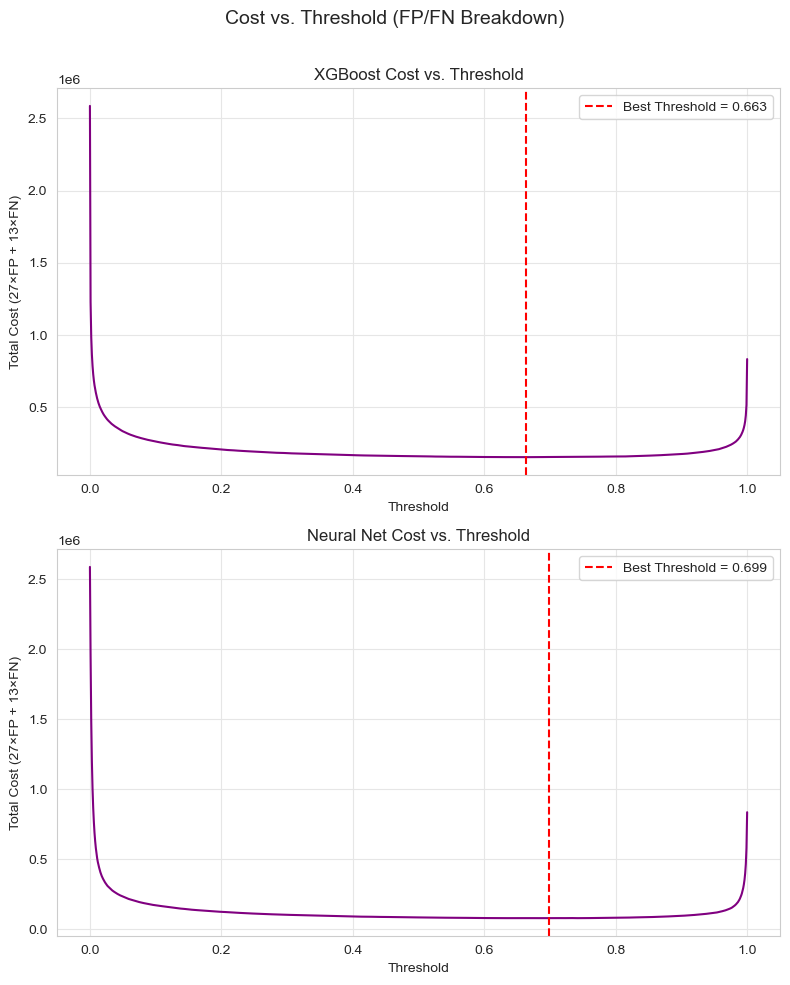

In [131]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))  # One column, two rows
plot_cost_curve_1line(thresholds, costs_xgb, best_thresh_xgb, "XGBoost", axes[0])
plot_cost_curve_1line(thresholds, costs_nn, best_thresh_nn, "Neural Net", axes[1])
fig.suptitle("Cost vs. Threshold (FP/FN Breakdown)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [132]:
# Compute with cost components
costs_xgb, fps_xgb, fns_xgb = compute_cost_components(y_true, probs_xgb, thresholds)
costs_nn, fps_nn, fns_nn = compute_cost_components(y_true, probs_nn, thresholds)

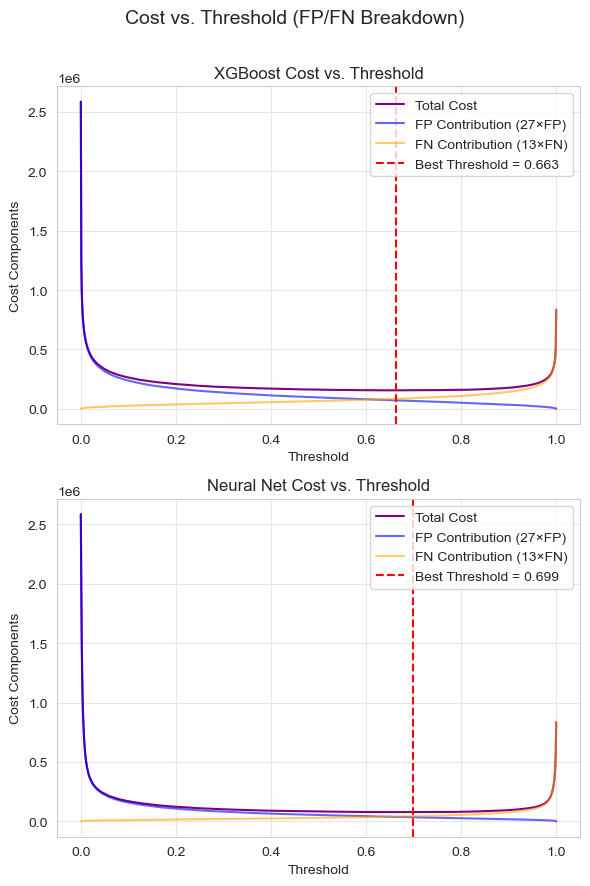

In [140]:
fig, axes = plt.subplots(2, 1, figsize=(6, 9))  # One column, two rows
plot_cost_curve(thresholds, costs_xgb, fps_xgb, fns_xgb, best_thresh_xgb, "XGBoost", axes[0])
plot_cost_curve(thresholds, costs_nn, fps_nn, fns_nn, best_thresh_nn, "Neural Net", axes[1])
fig.suptitle("Cost vs. Threshold (FP/FN Breakdown)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [ ]:
def plot_cost_curve(thresholds, costs, fps, fns, best_thresh, model_name, ax):
    ax.plot(thresholds, 27 * fps, label="FP Contribution (27×FP)", color='blue', alpha=0.9, linewidth=1.5)
    ax.plot(thresholds, 13 * fns, label="FN Contribution (13×FN)", color='green', alpha=0.9, linewidth=1.5)
    ax.axvline(best_thresh, linestyle='--', color='red', label=f"Best Threshold = {best_thresh:.3f}", alpha=0.9)
    ax.set_title(f"{model_name} Cost vs. Threshold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Error Cost by Type")
    ax.legend()
    ax.grid(True)


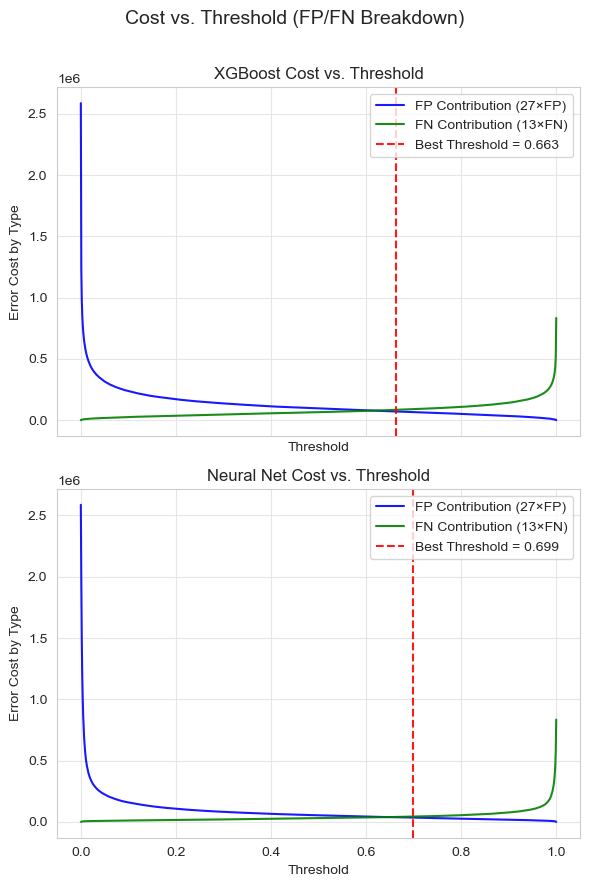

In [161]:
fig, axes = plt.subplots(2, 1, figsize=(6, 9), sharex=True)  # One column, two rows
plot_cost_curve(thresholds, costs_xgb, fps_xgb, fns_xgb, best_thresh_xgb, "XGBoost", axes[0])
plot_cost_curve(thresholds, costs_nn, fps_nn, fns_nn, best_thresh_nn, "Neural Net", axes[1])
fig.suptitle("Cost vs. Threshold (FP/FN Breakdown)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [218]:
def plot_cost_curve_col1(thresholds, costs, fps, fns, best_thresh, model_name, ax):
    ax.plot(thresholds, 27 * fps, label="FP Contribution (27×FP)", color='blue', alpha=0.9, linewidth=1.5)
    ax.plot(thresholds, 13 * fns, label="FN Contribution (13×FN)", color='green', alpha=0.9, linewidth=1.5)
    ax.axvline(best_thresh, linestyle='--', color='red', label=f"Best Threshold = {best_thresh:.3f}", alpha=0.9)
    ax.set_title(f"{model_name} Cost vs. Threshold", fontsize=13)
    ax.set_xlabel("Threshold", fontsize=12)
    ax.set_ylabel("Error Cost by Type", fontsize=12)
    ax.tick_params(axis='both', labelsize=11)      # Tick label font size
    ax.legend(fontsize=10)  # <- legend font size
    ax.grid(True)

def plot_cost_curve_col2(thresholds, costs, fps, fns, best_thresh, model_name, ax):
    ax.plot(thresholds, costs, label="Total Cost", color='purple', linewidth=1.5)
    ax.plot(thresholds, 27 * fps, label="FP Contribution (27×FP)", color='blue', alpha=0.9, linewidth=1.5)
    ax.plot(thresholds, 13 * fns, label="FN Contribution (13×FN)", color='green', alpha=0.9, linewidth=1.5)
    ax.axvline(best_thresh, linestyle='--', color='red', label=f"Best Threshold = {best_thresh:.3f}", alpha=0.9)
    ax.set_title(f"{model_name} Cost vs. Threshold", fontsize=13)
    ax.set_xlabel("Threshold", fontsize=12)
    ax.set_ylabel("Error Cost by Type", fontsize=12)
    ax.tick_params(axis='both', labelsize=11)      # Tick label font size
    ax.legend(fontsize=10)  # <- legend font size
    ax.grid(True)

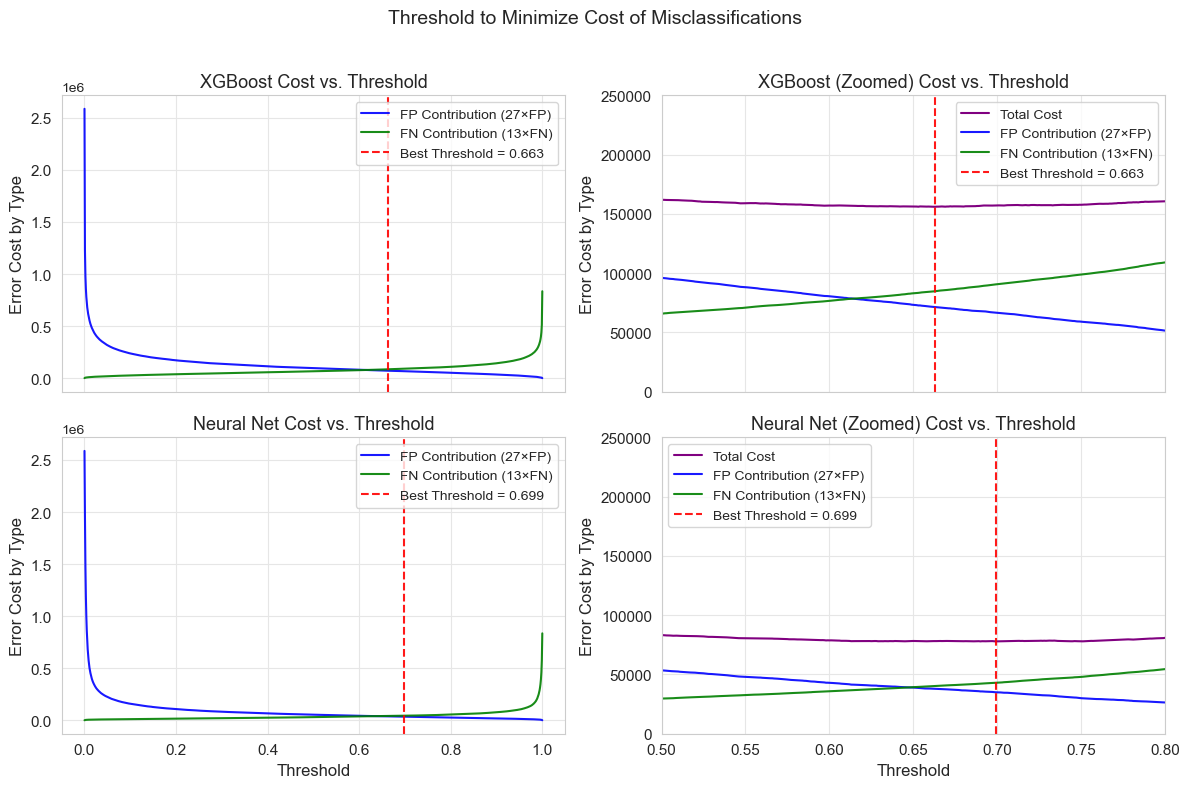

In [219]:
thresholds = np.linspace(0, 1, 1001)

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex='col')
fig.suptitle("Threshold to Minimize Cost of Misclassifications", fontsize=14)

# Full view
plot_cost_curve_col1(thresholds, costs_xgb, fps_xgb, fns_xgb, best_thresh_xgb, "XGBoost", axs[0, 0])
plot_cost_curve_col1(thresholds, costs_nn, fps_nn, fns_nn, best_thresh_nn, "Neural Net", axs[1, 0])

# Zoomed views (Y-axis zoom to show cost tradeoff more clearly)
plot_cost_curve_col2(thresholds, costs_xgb, fps_xgb, fns_xgb, best_thresh_xgb, "XGBoost (Zoomed)", axs[0, 1])
axs[0, 1].set_xlim(0.5, 0.8)
axs[0, 1].set_ylim(0, 2.5e5)  # adjust as needed

plot_cost_curve_col2(thresholds, costs_nn, fps_nn, fns_nn, best_thresh_nn, "Neural Net (Zoomed)", axs[1, 1])
axs[1, 1].set_xlim(0.5, 0.8)
axs[1, 1].set_ylim(0, 2.5e5)  # adjust to fit your data

# Hide top x-axis labels and tick labels
for ax in axs[0]:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=False)

# Optional: ensure bottom row has clear x-axis labels
for ax in axs[1]:
    ax.set_xlabel("Threshold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [210]:
def plot_conf_matrix(y_true, y_pred, model_name, ax, cmap='Blues'):
    disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f"{model_name}")
    ax.set_title(f"{model_name}", fontsize=14)  # Title font size
    ax.set_xlabel("Predicted Label", fontsize=12)  # X-axis label size
    ax.set_ylabel("True Label", fontsize=12)       # Y-axis label size
    ax.tick_params(axis='both', labelsize=12)      # Tick label font size

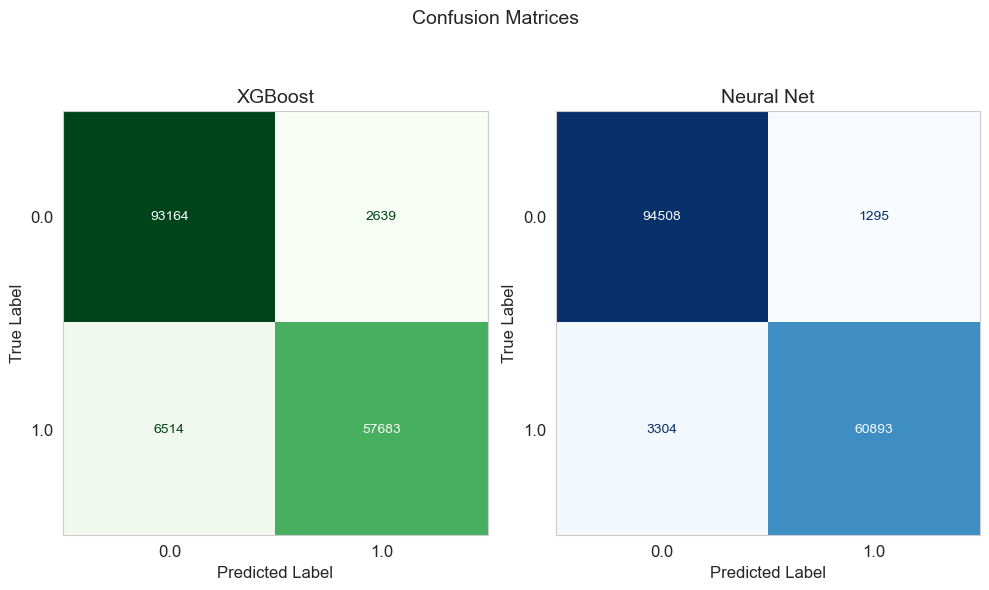

In [211]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
plot_conf_matrix(y_true, y_pred_xgb, "XGBoost", axes[0], cmap="Greens")
plot_conf_matrix(y_true, y_pred_nn, "Neural Net", axes[1])
axes[0].grid(False)
axes[1].grid(False)
fig.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


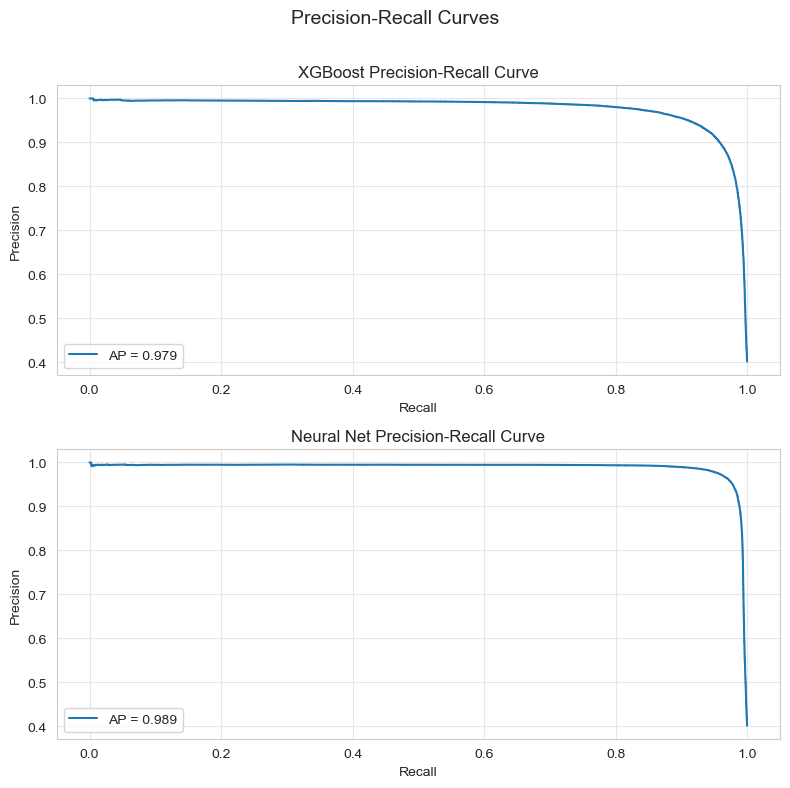

In [135]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
plot_pr_curve(y_true, probs_xgb, "XGBoost", axes[0])
plot_pr_curve(y_true, probs_nn, "Neural Net", axes[1])
fig.suptitle("Precision-Recall Curves", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


xgb 71253fp 84682fn 
nn 34965fp 42952